In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [2]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
from myproject.listRedshiftGalaxys import ListRedshiftGalaxy
from myproject.utilities.snapshotEnum import SnapshotEnum

from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, NullLocator, MultipleLocator


In [3]:
allSnapshotEnums = SnapshotEnum.getAllSnapshots()
# allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]

#get rid of snapshots < 50:
allSnapshotEnums = [snapshotEnum for snapshotEnum in allSnapshotEnums if snapshotEnum[0] >= 50]
allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]
print(allSnapshots)

[99, 91, 84, 78, 72, 67, 59, 50]


In [4]:
mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

In [5]:
listRedshiftGalaxyAnalysis = ListRedshiftGalaxy()
# listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG300-1', luminosityType='SDSS', generalErrorbar='poisson', generalRewrite=True)
listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG300-1', luminosityType='Default', generalErrorbar='poisson', generalRewrite=True)
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True)

Progress: 3732/3732
Loaded 3732 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
Progress: 3707/3707g Galaxy Group ID 3732 / 3732
Loaded 3707 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
Progress: 3643/3643g Galaxy Group ID 3707 / 3707
Loaded 3643 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
Progress: 3557/3557g Galaxy Group ID 3643 / 3643
Loaded 3557 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
Progress: 3388/3388g Galaxy Group ID 3557 / 3557
Loaded 3388 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p4/data/galaxy_data_TNG300-1_.hdf5
Progress: 3243/3243g Galaxy Group ID 3388 / 3388
Loaded 3243 galaxy groups from HDF5.
Loaded galaxy data from

## misc

In [10]:
#for snapshot 99, check how many subhalos have non nan joining redshifts compared to nan joining redshifts:
galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
num_subhalos = np.sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in galaxyAnalysis.loaded_list_of_galaxy_groups.getAllGalaxyGroups()])
num_subhalos_nan_joining_redshifts = 0
num_subhalos_non_nan_joining_redshifts = 0
for galaxy_group in galaxyAnalysis.loaded_list_of_galaxy_groups.getAllGalaxyGroups():
    for satellite_subhalo in galaxy_group.getSatelliteSubhalos():
        if np.isnan(satellite_subhalo.getJoiningRedshift()):
            num_subhalos_nan_joining_redshifts += 1
        else:
            num_subhalos_non_nan_joining_redshifts += 1
print(f"Snapshot 99: Num subhalos: {num_subhalos}, Num subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts}, Num subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts}")
print(f"Snapshot 99: Fraction of subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts/num_subhalos}, Fraction of subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts/num_subhalos}")

Snapshot 99: Num subhalos: 72199, Num subhalos with nan joining redshifts: 1428, Num subhalos with non-nan joining redshifts: 70771
Snapshot 99: Fraction of subhalos with nan joining redshifts: 0.019778667294560865, Fraction of subhalos with non-nan joining redshifts: 0.9802213327054391


In [7]:
#print num of clusters and satellites in each snapshot and mass bin:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup


for snapshotEnum in allSnapshotEnums:
    snapshot = snapshotEnum[0]
    print(f"Snapshot: {snapshot}")
    galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot)
    mass_bins : list[ListGalaxyGroup] = [
        galaxyAnalysis.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt15_list_of_galaxy_groups,
    ]
    for mass_bin, mass_bin_label in zip(mass_bins, mass_bin_labels):
        num_clusters = len(mass_bin.getAllGalaxyGroups())
        num_satellites = sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in mass_bin.getAllGalaxyGroups()])
        print(f" Mass bin: {mass_bin_label}, Num clusters: {num_clusters}, Num satellites: {num_satellites}")

Snapshot: 99
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2586, Num satellites: 20784
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 866, Num satellites: 20908
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 239, Num satellites: 16157
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 38, Num satellites: 7271
 Mass bin: $M_{200}>1e15$, Num clusters: 3, Num satellites: 1483
Snapshot: 91
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2366, Num satellites: 22629
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 780, Num satellites: 21745
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 192, Num satellites: 15591
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 26, Num satellites: 5609
 Mass bin: $M_{200}>1e15$, Num clusters: 2, Num satellites: 1057
Snapshot: 84
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2152, Num satellites: 23844
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 680, Num satellites: 21518
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 150, Num satellites: 13341
 Mass b

In [ ]:
#check in snapshot 0, that all galaxies in the gt13 ls13p5 mass bin have M200 between 1e13 and 1e13.5:
snapshotEnum = SnapshotEnum.SNAPSHOT_99
snapshot = snapshotEnum.value[0]
print(f"Snapshot: {snapshot}")
galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot)
mass_bin = galaxyAnalysis.filtered_gt13_ls13p5_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 1e13 and M200 < 10**13.5, f"Galaxy group with M200={M200:.2e} is not in the gt13 ls13p5 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt13p5_ls14_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**13.5 and M200 < 10**14, f"Galaxy group with M200={M200:.2e} is not in the gt13p5 ls14 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt14_ls14p5_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**14 and M200 < 10**14.5, f"Galaxy group with M200={M200:.2e} is not in the gt14 ls14p5 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt14p5_ls15_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**14.5 and M200 < 10**15, f"Galaxy group with M200={M200:.2e} is not in the gt14p5 ls15 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt15_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**15, f"Galaxy group with M200={M200:.2e} is not in the gt15 mass bin!"

In [ ]:
print(listRedshiftGalaxyAnalysis.getAllLoadedSnapshots())
print(SnapshotEnum.SNAPSHOT_99.value[0])
galaxyAnalysisZ0 = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(SnapshotEnum.SNAPSHOT_99.value[0])

[99, 91, 84, 78, 72, 67, 59, 50]
99


In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

# check snaphot compared to z=0

In [4]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [6]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])

    listRedshiftGG = []
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))

    listRedshiftGG.append(groupList)
    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_SDSS_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

Processing snapshot 91...
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p1, TNG300-1
Total Galaxy Groups to process: 220 with pairs : 1647602
Processing Subhalo 102/102 in Galaxy Group ID 99 with total pairs 51513COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 26/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/pairwise_polar_difference_tng300z0.1_vs_SDSS_tng300z0_TNG300-1
Processing snapshot 84...


Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
Processing snapshot 91...xy Group ID 3732 / 3732
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
Progres

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 112/112 in Galaxy Group ID 99 with total pairs 62160Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/pairwise_polar_difference_tng300z0.1_vs_tng300z0.1_default_luminosity_TNG300-1
Processing snapshot 84...
Progress: 3006/3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
Progress: 3006/3006g Galaxy Group ID 3006 / 3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Gro

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 96/96 in Galaxy Group ID 99 with total pairs 4560786Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p2/plots/pairwise_polar_difference_tng300z0.2_vs_tng300z0.2_default_luminosity_TNG300-1
Processing snapshot 78...
Progress: 2664/2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
Progress: 2664/2664g Galaxy Group ID 2664 / 2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Gro

...

Processing Subhalo 328/328 in Galaxy Group ID 9 with total pairs 536288Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/pairwise_polar_difference_tng300z0.5_vs_tng300z0.5_default_luminosity_TNG300-1
Processing snapshot 59...
Progress: 1531/1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
Progress: 1531/1531g Galaxy Group ID 1531 / 1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Gro

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 249/249 in Galaxy Group ID 9 with total pairs 308765Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p7/plots/pairwise_polar_difference_tng300z0.7_vs_tng300z0.7_default_luminosity_TNG300-1
Processing snapshot 50...
Progress: 900/900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
Progress: 900/900ing Galaxy Group ID 900 / 900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total 

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 132/132 in Galaxy Group ID 8 with total pairs 864658Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/pairwise_polar_difference_tng300z1.0_vs_tng300z1.0_default_luminosity_TNG300-1


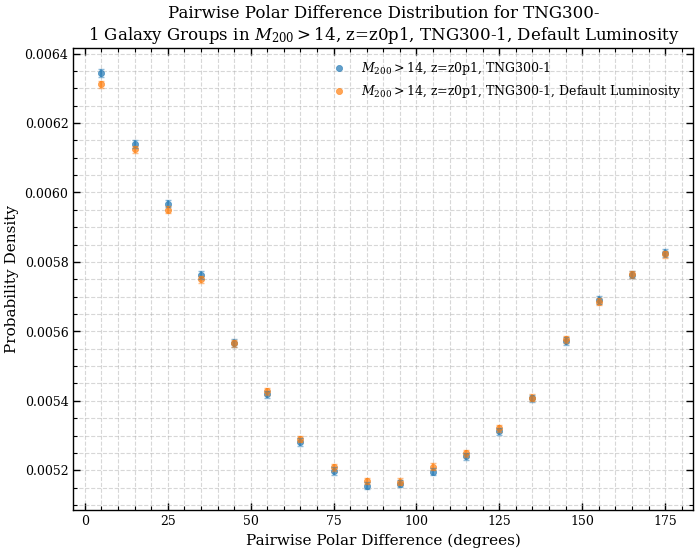

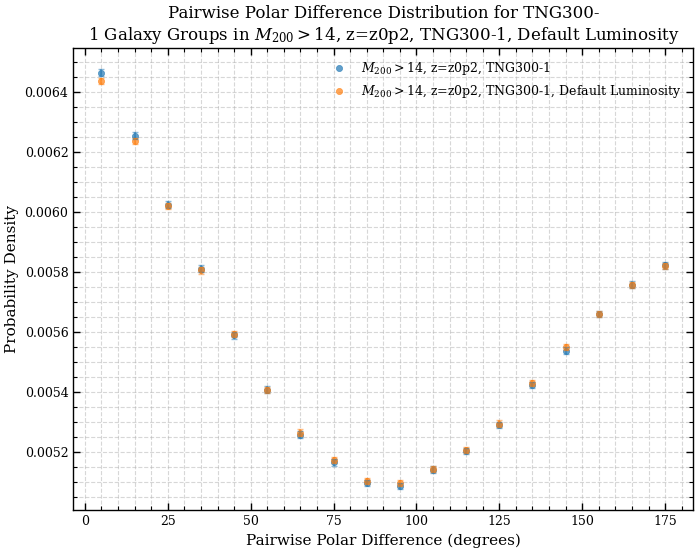

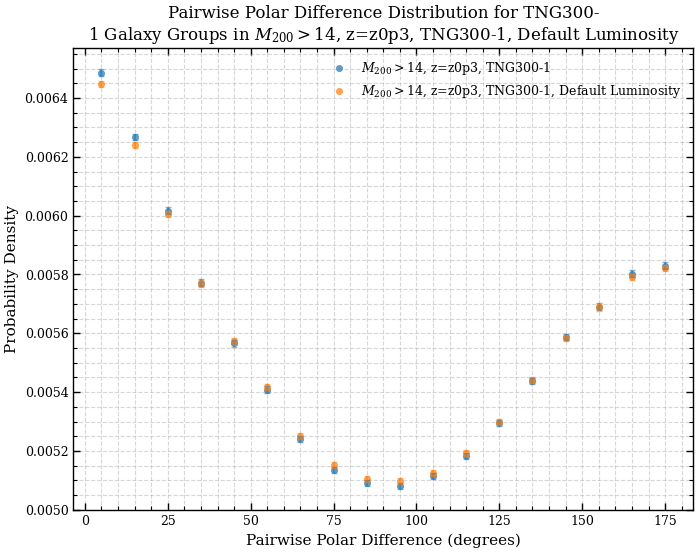

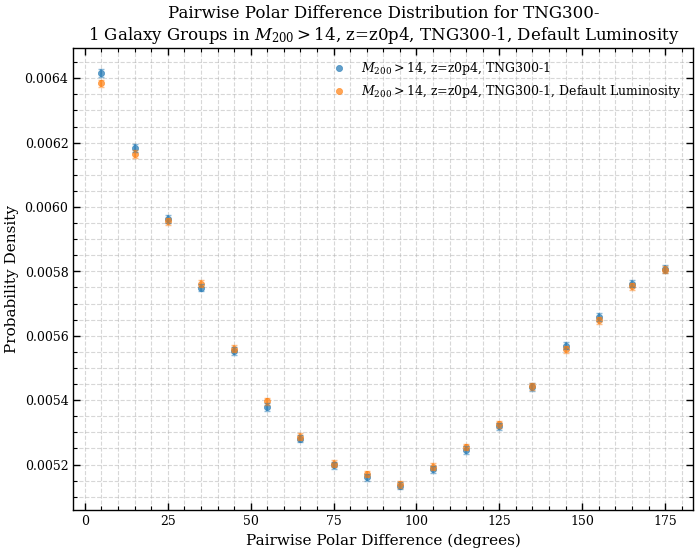

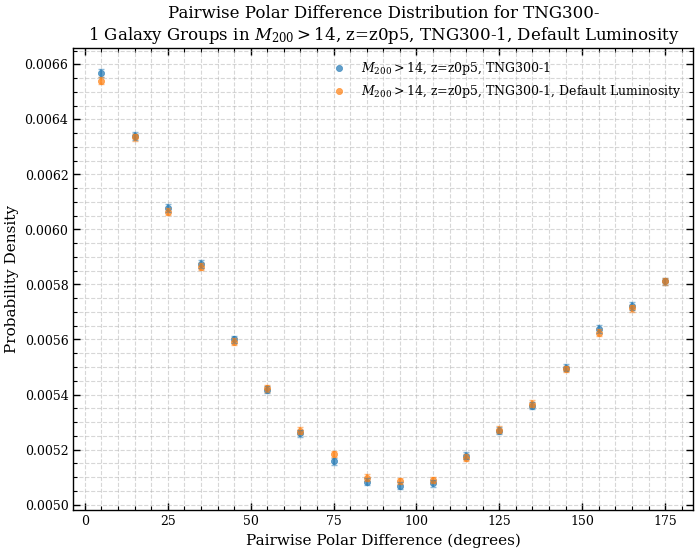

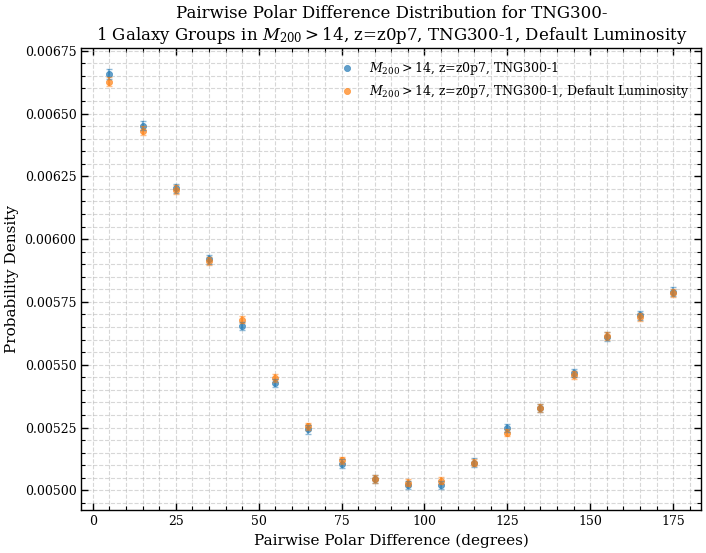

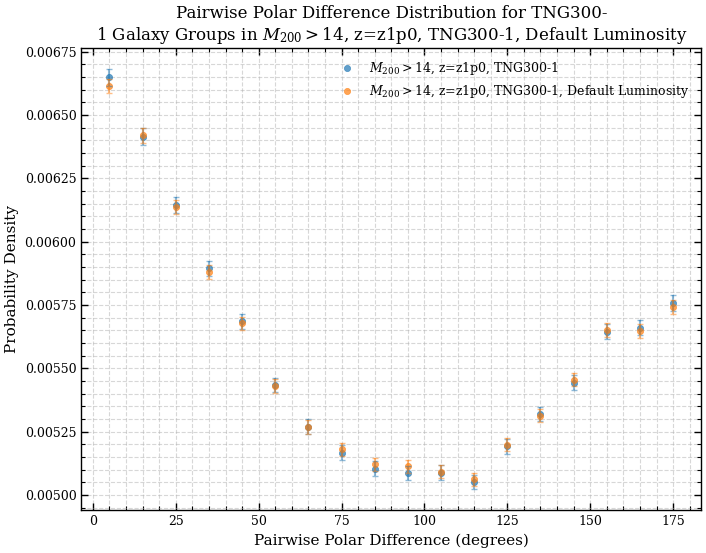

In [5]:
galaxyAnalysisZ0TNG300Default = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='Default')
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])
    galaxyAnalysisZ0TNG300Default.setSnapshot(snapshot[0], luminosityType='Default')

    listRedshiftGG = []
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    groupList.append((galaxyAnalysisZ0TNG300Default.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0TNG300Default.snapshot_dic[snapshot[0]][1]}, TNG300-1, Default Luminosity'))
    

    listRedshiftGG.append(groupList)
    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_default_luminosity_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

Processing snapshot 91...
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
final: [np.float64(0.06727626743690919), np.float64(0.08305598729203958), np.float64(0.039708743219627335)]
lenMRL: 660, lenrandom: (220, 3000)tribution for Galaxy Group 220 / 220 with 103 satellites
99th percentile MRL: 0.25809800675607114
Overall number of MRL values above 99th percentile: 79 out of 660
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477843)]


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2851969435172817
Overall number of MRL values above 99th percentile: 81 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/mrl_difference_tng300z0.1_vs_tng300z0_TNG300-1
Processing snapshot 84...
Progress: 3006/3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
final: [np.float64(0.06578292667682392), np.float64(0.15416648641861602), np.float64(0.14169104270824098)]
lenMRL: 522, lenrandom: (174, 3000)tribution for Galaxy Group 174 / 174 with 92 satel

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.28589199124443027
Overall number of MRL values above 99th percentile: 79 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p2/plots/mrl_difference_tng300z0.2_vs_tng300z0_TNG300-1
Processing snapshot 78...
Progress: 2664/2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
final: [np.float64(0.11210911223030663), np.float64(0.09161774232657646), np.float64(0.09437307886899875)]
lenMRL: 393, lenrandom: (131, 3000)tribution for Galaxy Group 131 / 131 with 73 sate

...

lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.28536515794304385
Overall number of MRL values above 99th percentile: 80 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/mrl_difference_tng300z0.5_vs_tng300z0_TNG300-1
Processing snapshot 59...
Progress: 1531/1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
final: [np.float64(0.16542763499370366), np.float64(0.1966326119423784), np.float64(0.14821200239290197)]
lenMRL: 102, lenrandom: (34, 3000)stribution for Galaxy Group 34 / 34 with 231 satell

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2859511999748071
Overall number of MRL values above 99th percentile: 79 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p7/plots/mrl_difference_tng300z0.7_vs_tng300z0_TNG300-1
Processing snapshot 50...
Progress: 900/900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
final: [np.float64(0.2210880946877993), np.float64(0.19496764891902507), np.float64(0.09695619315734465)]
lenMRL: 30, lenrandom: (10, 3000)istribution for Galaxy Group 10 / 10 with 121 satellites
99th percent

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2845650168701842
Overall number of MRL values above 99th percentile: 82 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/mrl_difference_tng300z1.0_vs_tng300z0_TNG300-1


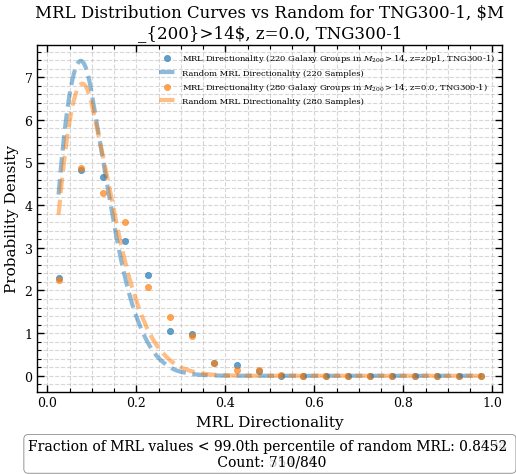

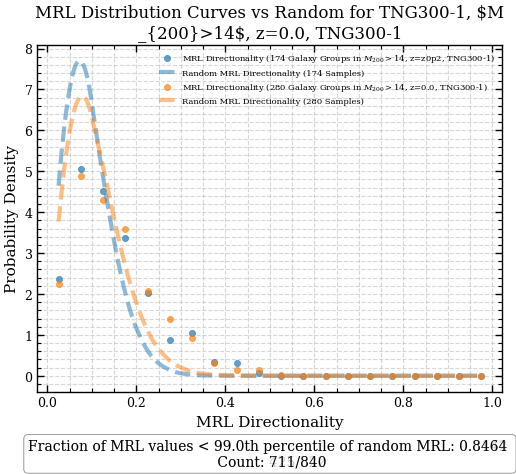

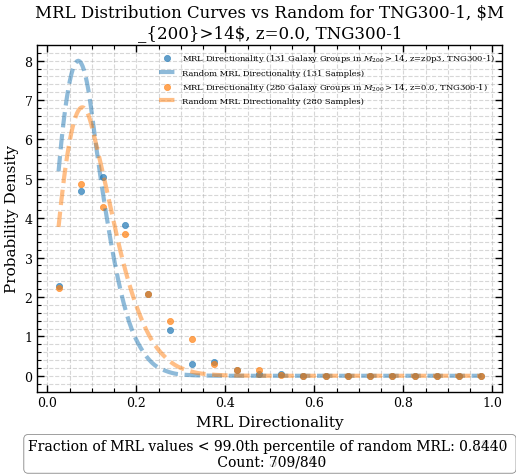

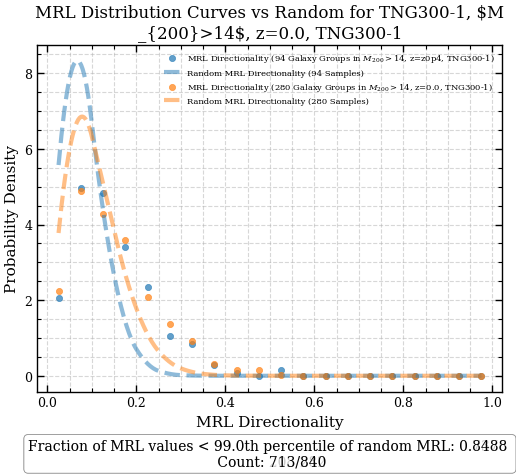

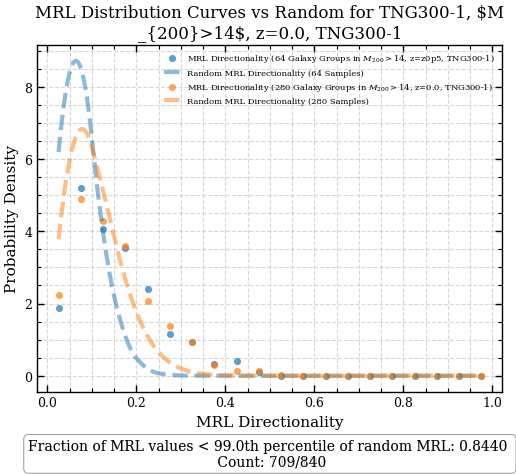

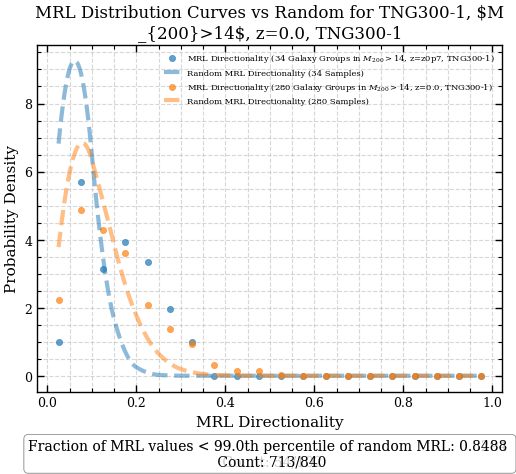

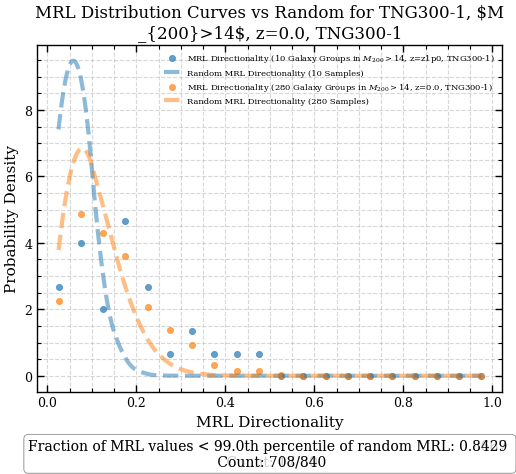

In [14]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] != 91: #already processed these snapshots
    #     continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")

    galaxyAnalysisZ0.setSnapshot(snapshot[0])

    listRedshiftGG = []

    listRedshiftGG.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    listRedshiftGG.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))


    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlayMRLAndMRLRandom(listGG=listRedshiftGG,oneaxis=True, savefig=False)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right', fontsize=6)  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/mrl_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

# overall change dependence

In [8]:
# get the percent of clusters below the 99% / 95% / 90% CL of random MRL, and plot it across redshift
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []
fracBelow99 = []
fracBelow95 = []
fracBelow90 = []

errBelow99 = []
errBelow95 = []
errBelow90 = []


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    redshifts.append(snapshot[1])

    # Note: getPercentOfClustersAboveRandomMRLCL returns the fraction/count/total *below* the percentile.
    (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=99
    )
    (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=95
    )
    (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=90
    )

    fracBelow99.append(f99)
    fracBelow95.append(f95)
    fracBelow90.append(f90)

    errBelow99.append(binomial_sigma(f99, n99))
    errBelow95.append(binomial_sigma(f95, n95))
    errBelow90.append(binomial_sigma(f90, n90))

Processing snapshot 99...
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477845)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.8512 (715/840)tess
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477845)]
Fraction of MRL values below the 95th percentile of random MRL values: 0.7500 (630/840)tess
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477845)]
Fraction of MRL values below the 90th percentile of random MRL values: 0.6821 (573/840)tess
Processing snapshot 91...
final: [np.float64(0.06727626743690919), np.float64(0.0830559872920396), np.float64(0.039708743219627335)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.8348 (551/660)ites
final: [np.float64(0.06727626743690919), np.float64(0.0830559872920396), np.float64(0.039708743219627335)]
Fraction of MRL values below the 95th percent

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_TNG300-1


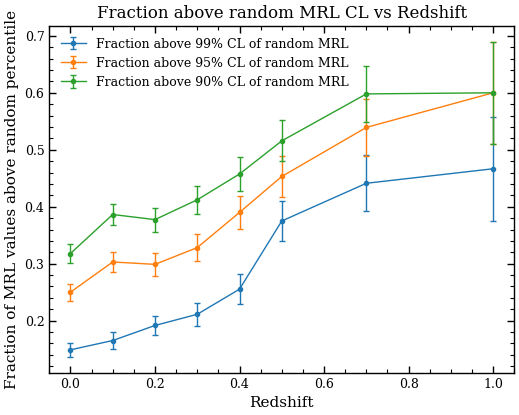

In [9]:
MRL_CL_plotter = AstroPlotter()
MRL_CL_fig, MRL_CL_ax = MRL_CL_plotter.create_figure()

MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow99),
    yerr=errBelow99,
    label='Fraction above 99% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow95),
    yerr=errBelow95,
    label='Fraction above 95% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow90),
    yerr=errBelow90,
    label='Fraction above 90% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

MRL_CL_ax.set_xlabel('Redshift')
MRL_CL_ax.set_ylabel('Fraction of MRL values above random percentile')
MRL_CL_ax.set_title('Fraction above random MRL CL vs Redshift')
MRL_CL_ax.legend(loc='upper left')

MRL_CL_plotter.save_figure(
    MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [10]:
# do the same but for the 5 mass groups
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []

mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

fracBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

errBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])

    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]

    redshifts.append(snapshot[1])

    for i, mass_bin in enumerate(mass_bins):
        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False, num_samples=1000
        )

        (f99, c99, n99,_), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=99, random_mrl_values=random_MRL_values
        )
        (f95, c95, n95,_), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=95, random_mrl_values=random_MRL_values
        )
        (f90, c90, n90,_), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=90, random_mrl_values=random_MRL_values
        )

        fracBelow99_mass_bins[i].append(f99)
        fracBelow95_mass_bins[i].append(f95)
        fracBelow90_mass_bins[i].append(f90)

        errBelow99_mass_bins[i].append(binomial_sigma(f99, n99))
        errBelow95_mass_bins[i].append(binomial_sigma(f95, n95))
        errBelow90_mass_bins[i].append(binomial_sigma(f90, n90))

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.9568 (7423/7758)tes
Fraction of MRL values below the 95th percentile of random MRL values: 0.8986 (6971/7758)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8408 (6523/7758)
Fraction of MRL values below the 99th percentile of random MRL values: 0.9496 (2467/2598)s
Fraction of MRL values below the 95th percentile of random MRL values: 0.8722 (2266/2598)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8079 (2099/2598)
Fraction of MRL values below the 99th percentile of random MRL values: 0.8717 (625/717)tess
Fraction of MRL values below the 95th percentile of random MRL values: 0.7796 (559/717)
Fraction of MRL values below the 90th percentile of random MRL values: 0.7127 (511/717)
Fraction of MRL values below the 99th percentile of random MRL values: 0.7105 (81/114)tes
Fraction of MRL values below the 95th percentile of random MRL values: 0

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_TNG300-1


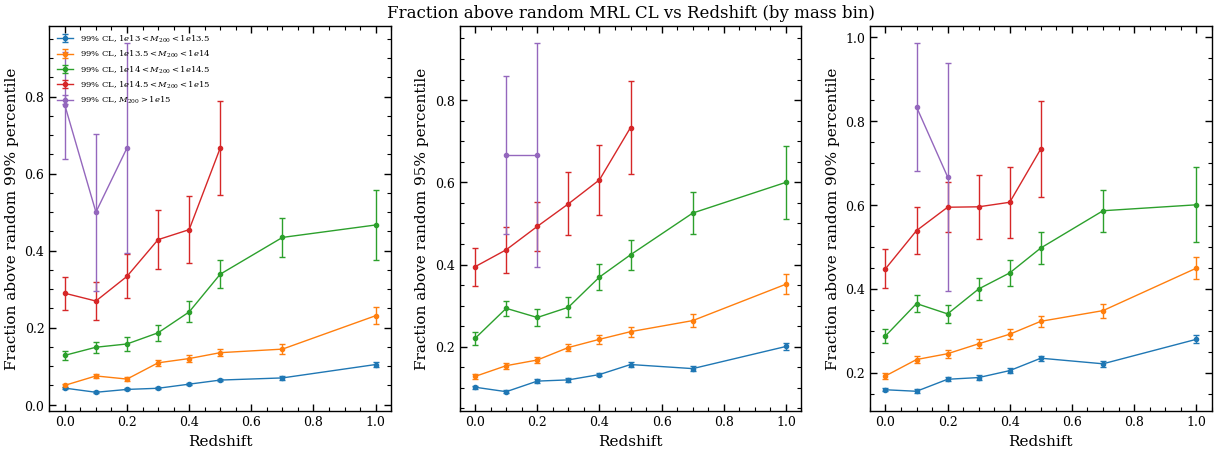

In [11]:
mass_bin_MRL_CL_plotter = AstroPlotter()
mass_bin_MRL_CL_fig, mass_bin_MRL_CL_ax = mass_bin_MRL_CL_plotter.create_figure(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
)  # each col is a different confidence level, each line is a different mass bin


redshifts = SnapshotEnum.getAllRedshifts()[:8]


for i in range(len(mass_bin_labels)):
    y99 = np.array(fracBelow99_mass_bins[i], dtype=float)
    mask99 = y99 != 0
    if np.any(mask99):
        mass_bin_MRL_CL_ax[0].errorbar(
            np.array(redshifts)[mask99],
            1 - y99[mask99],
            yerr=np.array(errBelow99_mass_bins[i])[mask99],
            label=f'99% CL, {mass_bin_labels[i]}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )
    y95 = np.array(fracBelow95_mass_bins[i], dtype=float)
    mask95 = y95 != 0
    if np.any(mask95):
        mass_bin_MRL_CL_ax[1].errorbar(
            np.array(redshifts)[mask95],
            1 - y95[mask95],
            yerr=np.array(errBelow95_mass_bins[i])[mask95],
            label=f'95% CL, {mass_bin_labels[i]}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )
    y90 = np.array(fracBelow90_mass_bins[i], dtype=float)
    mask90 = y90 != 0
    if np.any(mask90):
        mass_bin_MRL_CL_ax[2].errorbar(
            np.array(redshifts)[mask90],
            1 - y90[mask90],
            yerr=np.array(errBelow90_mass_bins[i])[mask90],
            label=f'90% CL, {mass_bin_labels[i]}',
            marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )

mass_bin_MRL_CL_ax[0].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[1].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[2].set_xlabel('Redshift')

mass_bin_MRL_CL_ax[0].set_ylabel('Fraction above random 99% percentile')
mass_bin_MRL_CL_ax[1].set_ylabel('Fraction above random 95% percentile')
mass_bin_MRL_CL_ax[2].set_ylabel('Fraction above random 90% percentile')

mass_bin_MRL_CL_ax[1].set_title('Fraction above random MRL CL vs Redshift (by mass bin)')

mass_bin_MRL_CL_ax[0].legend(fontsize=6, loc='upper left')

mass_bin_MRL_CL_plotter.save_figure(
    mass_bin_MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [12]:
#take the difference of polar pairwise < 90º with polar pairwise > 90º and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

def polar_lt90_ge90_stats_from_hist(angles_deg, bin_size_deg=5.0):
    """
    Compute counts and fractions using a (normalized) histogram with an edge at 90°.

    Returns a dict with:
      - total
      - n_lt90, n_ge90 (expected counts from histogram; equals counts for equal weights)
      - frac_lt90, frac_ge90 (fractions; sum to 1 when total>0)
      - diff = n_lt90 - n_ge90
      - sigma_poisson = sqrt(n_lt90 + n_ge90)
    """
    angles = np.asarray(angles_deg, dtype=float)
    if angles.size == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    bins = np.arange(0.0, 180.0 + bin_size_deg, bin_size_deg)
    counts, edges = np.histogram(angles, bins=bins)
    total = int(counts.sum())
    if total == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    # normalized histogram (probability mass per bin)
    prob = counts / total
    lt_mask = edges[:-1] < 90.0  # bins with left edge < 90° are counted as <90° (e.g. [85,90))
    frac_lt90 = float(prob[lt_mask].sum())
    frac_ge90 = float(prob[~lt_mask].sum())
    # expected counts from normalized histogram
    n_lt90 = frac_lt90 * total
    n_ge90 = frac_ge90 * total
    diff = n_lt90 - n_ge90
    sigma_poisson = float(np.sqrt(n_lt90 + n_ge90))
    return {
        'total': total,
        'n_lt90': float(n_lt90),
        'n_ge90': float(n_ge90),
        'frac_lt90': float(frac_lt90),
        'frac_ge90': float(frac_ge90),
        'diff': float(diff),
        'sigma_poisson': float(sigma_poisson),
    }

redshifts = []

# values used for plotting (counts-difference + poisson errors)
polarDifference_full_sample = []
polarDifference_full_sample_err = []
polarDifference_mass_bins = []
polarDifference_mass_bins_err = []

# keep both expected counts and fractions for later inspection/analysis
full_total_pairs = []
full_n_lt90 = []
full_n_ge90 = []
full_frac_lt90 = []
full_frac_ge90 = []

mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
mass_total_pairs = [[] for _ in range(len(mass_bin_labels))]
mass_n_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_n_ge90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_ge90 = [[] for _ in range(len(mass_bin_labels))]

polarDifference_mass_bins = [[] for _ in range(len(mass_bin_labels))]
polarDifference_mass_bins_err = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    
    # Build the "full sample" by accumulating angles from the mass bins,
    # so we don't recompute the polar differences twice.
    full_angles = []
    for i, mass_bin in enumerate(mass_bins):
        polarRawValues = mass_bin.compute_probablity_distribution_of_polar_differences()
        full_angles.extend(polarRawValues)
        stats = polar_lt90_ge90_stats_from_hist(polarRawValues, bin_size_deg=5.0)
        polarDifference_mass_bins[i].append(stats['diff'])
        polarDifference_mass_bins_err[i].append(stats['sigma_poisson'])
        mass_total_pairs[i].append(stats['total'])
        mass_n_lt90[i].append(stats['n_lt90'])
        mass_n_ge90[i].append(stats['n_ge90'])
        mass_frac_lt90[i].append(stats['frac_lt90'])
        mass_frac_ge90[i].append(stats['frac_ge90'])
    
    stats_full = polar_lt90_ge90_stats_from_hist(full_angles, bin_size_deg=5.0)
    polarDifference_full_sample.append(stats_full['diff'])
    polarDifference_full_sample_err.append(stats_full['sigma_poisson'])
    full_total_pairs.append(stats_full['total'])
    full_n_lt90.append(stats_full['n_lt90'])
    full_n_ge90.append(stats_full['n_ge90'])
    full_frac_lt90.append(stats_full['frac_lt90'])
    full_frac_ge90.append(stats_full['frac_ge90'])

Processing snapshot 99...
Total Galaxy Groups to process: 2586 with pairs : 114289
Processing Subhalo 10/10 in Galaxy Group ID 993 with total pairs 4555Total Galaxy Groups to process: 866 with pairs : 298317
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 6618Total Galaxy Groups to process: 239 with pairs : 619694
Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Total Galaxy Groups to process: 38 with pairs : 758114
Processing Subhalo 267/267 in Galaxy Group ID 9 with total pairs 355111Total Galaxy Groups to process: 3 with pairs : 376094
Processing Subhalo 386/386 in Galaxy Group ID 2 with total pairs 743051Processing snapshot 91...
Total Galaxy Groups to process: 2366 with pairs : 143039
Processing Subhalo 7/7 in Galaxy Group ID 996 with total pairs 216635Total Galaxy Groups to process: 780 with pairs : 354305
Processing Subhalo 13/13 in Galaxy Group ID 1000 with total pairs 786Total Galaxy Groups to process: 192 with pairs : 714584
Processing S

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_TNG300-1


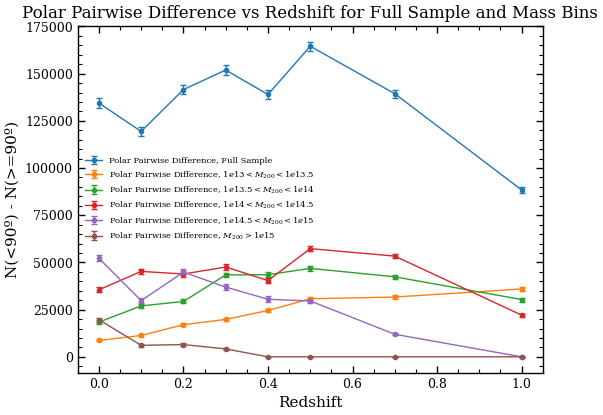

In [13]:
polarPairwiseDifference_plotter = AstroPlotter()
polarPairwiseDifference_fig, polarPairwiseDifference_ax = polarPairwiseDifference_plotter.create_figure()
polarPairwiseDifference_ax.errorbar(
    redshifts,
    polarDifference_full_sample,
    yerr=polarDifference_full_sample_err,
    label='Polar Pairwise Difference, Full Sample',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
    )
for i in range(len(mass_bin_labels)):
    polarPairwiseDifference_ax.errorbar(
        redshifts,
        polarDifference_mass_bins[i],
        yerr=polarDifference_mass_bins_err[i],
        label=f'Polar Pairwise Difference, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
polarPairwiseDifference_ax.set_xlabel('Redshift')
polarPairwiseDifference_ax.set_ylabel('N(<90º) - N(>=90º)')
polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifference_ax.legend(fontsize=6)
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_poisson_propagated_TNG300-1


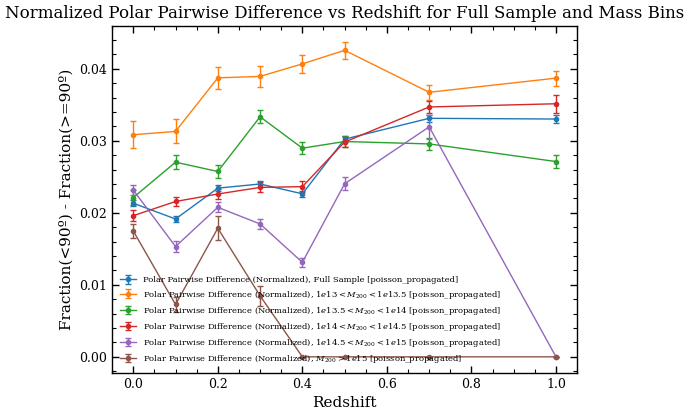

In [14]:
#take the difference of polar pairwise < 90º with polar pairwise > 90º and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
# plot the normalized version of the above (frac(<90º) - frac(>=90º)) vs redshift for the full sample and mass bins
import numpy as np

# Choose error model for d = f_lt - f_ge
# - 'binomial': previous multinomial/binomial approximation
# - 'poisson_propagated': Poisson on <90 and >=90 counts, normalized by N, then propagated
error_model = 'poisson_propagated'  # set to 'binomial' to recover the previous behavior

def frac_diff_and_sigma(frac_lt, frac_ge, n_total, n_lt, n_ge, model='binomial'):
    d = float(frac_lt) - float(frac_ge)
    n = int(n_total)
    if n <= 0:
        return d, 0.0

    if model == 'binomial':
        # Previous formula: Var(d) = (1 - d^2) / N
        sigma = float(np.sqrt(max(0.0, 1.0 - d * d) / n))
        return d, sigma

    if model == 'poisson_propagated':
        # Poisson on counts, then normalize to fractions by N
        sigma_f_lt = np.sqrt(max(float(n_lt), 0.0)) / n
        sigma_f_ge = np.sqrt(max(float(n_ge), 0.0)) / n
        sigma = float(np.sqrt(sigma_f_lt**2 + sigma_f_ge**2))
        return d, sigma

    raise ValueError(f'Unknown error model: {model}')

full_frac_diff = []
full_frac_diff_err = []
for frac_lt, frac_ge, n, n_lt, n_ge in zip(full_frac_lt90, full_frac_ge90, full_total_pairs, full_n_lt90, full_n_ge90):
    d, s = frac_diff_and_sigma(frac_lt, frac_ge, n, n_lt, n_ge, model=error_model)
    full_frac_diff.append(d)
    full_frac_diff_err.append(s)

mass_frac_diff = [[] for _ in range(len(mass_bin_labels))]
mass_frac_diff_err = [[] for _ in range(len(mass_bin_labels))]
for i in range(len(mass_bin_labels)):
    for frac_lt, frac_ge, n, n_lt, n_ge in zip(
        mass_frac_lt90[i],
        mass_frac_ge90[i],
        mass_total_pairs[i],
        mass_n_lt90[i],
        mass_n_ge90[i],
    ):
        d, s = frac_diff_and_sigma(frac_lt, frac_ge, n, n_lt, n_ge, model=error_model)
        mass_frac_diff[i].append(d)
        mass_frac_diff_err[i].append(s)

polarPairwiseDifferenceNorm_plotter = AstroPlotter()
polarPairwiseDifferenceNorm_fig, polarPairwiseDifferenceNorm_ax = polarPairwiseDifferenceNorm_plotter.create_figure()

polarPairwiseDifferenceNorm_ax.errorbar(
    redshifts,
    full_frac_diff,
    yerr=full_frac_diff_err,
    label=f'Polar Pairwise Difference (Normalized), Full Sample [{error_model}]',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

for i in range(len(mass_bin_labels)):
    polarPairwiseDifferenceNorm_ax.errorbar(
        redshifts,
        mass_frac_diff[i],
        yerr=mass_frac_diff_err[i],
        label=f'Polar Pairwise Difference (Normalized), {mass_bin_labels[i]} [{error_model}]',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )

polarPairwiseDifferenceNorm_ax.set_xlabel('Redshift')
polarPairwiseDifferenceNorm_ax.set_ylabel('Fraction(<90º) - Fraction(>=90º)')
polarPairwiseDifferenceNorm_ax.set_title('Normalized Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifferenceNorm_ax.legend(fontsize=6)

polarPairwiseDifferenceNorm_plotter.save_figure(
    polarPairwiseDifferenceNorm_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_{error_model}_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

# more reliable assymetry

In [6]:
#try a different method:
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np

def asymetryPlots(
    redshifts,
    listRedshiftGG: list[list[ListGalaxyGroup]],
    listGGLabels,
    plotRows=1,
    plotCols=1,
    ax=None,
    fig=None,
    plotter=None,
    title=None,
):
    """Plot asymmetry curves on either a fresh axis or a provided axis (for multipanel use)."""

    polar_pairwise_by_type_by_redshift: dict[float, dict[str, dict[str, list]]] = {}
    # dict of snapshot -> type -> {'differences': [], 'binned': [], 'bin_centers': [], 'errorbars': []}

    for snapshot, mass_bins in zip(redshifts, listRedshiftGG):
        polar_pairwise_by_type: dict[str, dict[str, list]] = {}
        extended_list_of_full_sample_polar_differences = []
        extended_full_sample_pairwise_polar_differences_binned = None
        extended_full_sample_polar_bin_centers = None
        extended_full_sample_pairwise_polar_errorbars = None

        for i, mass_bin in enumerate(mass_bins):
            list_pairwise_polar_differences = mass_bin.compute_probablity_distribution_of_polar_differences(parallelize=False)

            pairwise_polar_differences_binned, polar_bin_centers, pairwise_polar_errorbars = ListGalaxyGroup.get_histogram_bins(
                list_pairwise_polar_differences,
                bins=np.arange(0, 185, 10),
                errorbarType='bootstrap',
                normalize_to_one=True,
            )

            label_key = listGGLabels[i]
            polar_pairwise_by_type[label_key] = {
                'differences': list_pairwise_polar_differences,
                'binned': pairwise_polar_differences_binned,
                'bin_centers': polar_bin_centers,
                'errorbars': pairwise_polar_errorbars,
            }

            extended_list_of_full_sample_polar_differences = (
                extended_list_of_full_sample_polar_differences + list_pairwise_polar_differences
            )

            if extended_full_sample_pairwise_polar_differences_binned is None:
                extended_full_sample_pairwise_polar_differences_binned = np.array(pairwise_polar_differences_binned, dtype=float)
                extended_full_sample_polar_bin_centers = np.array(polar_bin_centers, dtype=float)
                extended_full_sample_pairwise_polar_errorbars = np.array(pairwise_polar_errorbars, dtype=float)
            else:
                extended_full_sample_pairwise_polar_differences_binned = (
                    extended_full_sample_pairwise_polar_differences_binned + np.array(pairwise_polar_differences_binned, dtype=float)
                )
                extended_full_sample_pairwise_polar_errorbars = (
                    extended_full_sample_pairwise_polar_errorbars + np.array(pairwise_polar_errorbars, dtype=float)
                )

        polar_pairwise_by_type['full_sample'] = {
            'differences': extended_list_of_full_sample_polar_differences,
            'binned': extended_full_sample_pairwise_polar_differences_binned,
            'bin_centers': extended_full_sample_polar_bin_centers,
            'errorbars': extended_full_sample_pairwise_polar_errorbars,
        }

        polar_pairwise_by_type_by_redshift[snapshot] = polar_pairwise_by_type

    # Sum points below 90 deg and above/equal 90 deg, propagate poisson errors in quadrature.
    for redshift, polar_pairwise_by_type in polar_pairwise_by_type_by_redshift.items():
        for type_key, stats in polar_pairwise_by_type.items():
            lt90_mask = stats['bin_centers'] < 90.0
            ge90_mask = stats['bin_centers'] >= 90.0
            n_lt90 = np.sum(stats['binned'][lt90_mask])
            n_ge90 = np.sum(stats['binned'][ge90_mask])
            diff = n_lt90 - n_ge90
            sigma_poisson = np.sqrt(
                np.sum(stats['errorbars'][lt90_mask] ** 2) + np.sum(stats['errorbars'][ge90_mask] ** 2)
            )
            polar_pairwise_by_type_by_redshift[redshift][type_key]['diff'] = diff
            polar_pairwise_by_type_by_redshift[redshift][type_key]['diff_err'] = sigma_poisson

    by_mass_diff = {type_key: [] for type_key in listGGLabels}
    by_mass_diff_err = {type_key: [] for type_key in listGGLabels}
    redshift_list = []

    for redshift, polar_pairwise_by_type in polar_pairwise_by_type_by_redshift.items():
        redshift_list.append(redshift)
        for type_key in listGGLabels:
            by_mass_diff[type_key].append(polar_pairwise_by_type[type_key]['diff'])
            by_mass_diff_err[type_key].append(polar_pairwise_by_type[type_key]['diff_err'])

    if ax is None:
        polarPairwiseDifference_plotter = AstroPlotter() if plotter is None else plotter
        polarPairwiseDifference_fig, polarPairwiseDifference_ax = polarPairwiseDifference_plotter.create_figure(
            nrows=plotRows, ncols=plotCols
        )
    else:
        polarPairwiseDifference_ax = ax
        polarPairwiseDifference_fig = fig if fig is not None else ax.figure
        polarPairwiseDifference_plotter = plotter

    for type_key in listGGLabels:
        polarPairwiseDifference_ax.errorbar(
            redshift_list,
            by_mass_diff[type_key],
            yerr=by_mass_diff_err[type_key],
            label=f'{type_key}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )

    polarPairwiseDifference_ax.set_xlabel('Redshift')
    polarPairwiseDifference_ax.set_ylabel('N(<90º) - N(>=90º)')
    if title is not None:
        polarPairwiseDifference_ax.set_title(title)
    polarPairwiseDifference_ax.legend(fontsize=8)

    return (
        polarPairwiseDifference_plotter,
        polarPairwiseDifference_fig,
        polarPairwiseDifference_ax,
        polar_pairwise_by_type_by_redshift,
    )

Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...
Total Galaxy Groups to process: 2586 with pairs : 131308
Progress: Processing Galaxy Group ID 1065, 18 / 2586

Progress: Processing Galaxy Group ID 993, 2586 / 25866Total Galaxy Groups to process: 866 with pairs : 350183
Progress: Processing Galaxy Group ID 999, 866 / 8666Total Galaxy Groups to process: 239 with pairs : 732633
Progress: Processing Galaxy Group ID 99, 239 / 2399Total Galaxy Groups to process: 38 with pairs : 891546
Progress: Processing Galaxy Group ID 9, 38 / 388Total Galaxy Groups to process: 3 with pairs : 444223
Progress: Processing Galaxy Group ID 2, 3 / 3Total Galaxy Groups to process: 2585 with pairs : 149715
Progress: Processing Galaxy Group ID 996, 2585 / 25855Total Galaxy Groups to process: 872 with pairs : 393531
Progress: Processing Galaxy Group ID 999, 872 / 8722Total Galaxy Groups to process: 218 with pairs : 820875
Progress: Processing Galaxy Group ID 99, 218 / 2188Total Galaxy Groups to process: 30 with pairs : 823660
Progress: Processing Galaxy Group ID 9, 30 / 300Total Galaxy Groups to process: 2 with pairs : 330028
Progress: Processing Galaxy Group ID 1, 2 / 2T

Text(0.5, 1.0, 'Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')

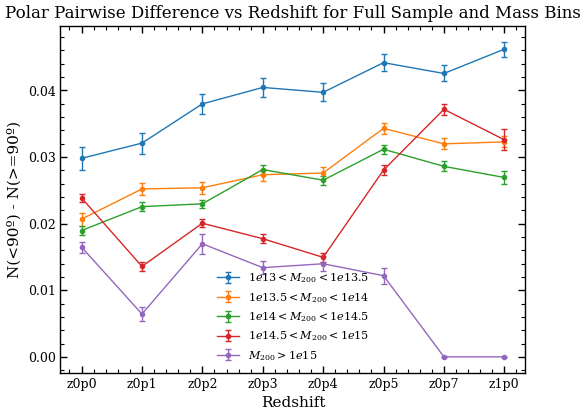

In [7]:


mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
redshift_mass_bins : list[list[ListGalaxyGroup]]= []
redshifts = []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])
    redshift_mass_bins.append(mass_bins)
    
polarPairwiseDifference_plotter, polarPairwiseDifference_fig, polarPairwiseDifference_ax, polar_pairwise_by_type_by_redshift = asymetryPlots(redshifts, listRedshiftGG=redshift_mass_bins, listGGLabels=mass_bin_labels, plotRows=1, plotCols=1)

polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
# polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/static_mass_polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')
    

In [13]:
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
print(polar_pairwise_by_type_by_redshift['z0p0'].keys())
print("\nMass bin: $1e14<M_{200}<1e14.5$")
print(f" Num of clusters: {len(galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f" Assymetry value: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14<M_{200}<1e14.5$']['diff']}")
print(f" Assymetry error: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14<M_{200}<1e14.5$']['diff_err']}")

print("\nMass bin: $1e14.5<M_{200}<1e15$")
print(f" Num of clusters: {len(galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f" Assymetry value: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14.5<M_{200}<1e15$']['diff']}")
print(f" Assymetry error: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14.5<M_{200}<1e15$']['diff_err']}")

print("\nMass bin: $M_{200}>1e15$")
print(f" Num of clusters: {len(galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f" Assymetry value: {polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['diff']}")
print(f" Assymetry error: {polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['diff_err']}")


dict_keys(['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$', 'full_sample'])

Mass bin: $1e14<M_{200}<1e14.5$
 Num of clusters: 239
 Assymetry value: 0.0189568488696516
 Assymetry error: 0.0006827672566540679

Mass bin: $1e14.5<M_{200}<1e15$
 Num of clusters: 38
 Assymetry value: 0.02384948176179491
 Assymetry error: 0.0006141791290487111

Mass bin: $M_{200}>1e15$
 Num of clusters: 3
 Assymetry value: 0.01646216052771704
 Assymetry error: 0.0008678172351569394


In [18]:
#get the counts for M200c > 1e15 thats < 90º and >= 90º for the z=0 snapshot and its error
print(np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned']) < 90), np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned']) >= 90), polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['diff_err'])

lt90_mask = np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['bin_centers']) < 90
ge90_mask = np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['bin_centers']) >= 90
lt90_count = np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned'][lt90_mask]))
ge90_count = np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned'][ge90_mask]))
lt90_error = np.sqrt(np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['errorbars'][lt90_mask]) ** 2))
ge90_error = np.sqrt(np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['errorbars'][ge90_mask]) ** 2))
print(f"Counts < 90º: {lt90_count} ± {lt90_error}")
print(f"Counts >= 90º: {ge90_count} ± {ge90_error}")

18 0 0.0008678172351569394
Counts < 90º: 0.5082310802638585 ± 0.0006186697495062649
Counts >= 90º: 0.4917689197361415 ± 0.0006085675761008716


In [8]:
#bootstrap
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
print(polar_pairwise_by_type_by_redshift['z0p0'].keys())
print("\nBootstrap Mass bin: $1e14<M_{200}<1e14.5$")
print(f" Num of clusters: {len(galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f" Assymetry value: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14<M_{200}<1e14.5$']['diff']}")
print(f" Assymetry error: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14<M_{200}<1e14.5$']['diff_err']}")

print("\nMass bin: $1e14.5<M_{200}<1e15$")
print(f" Num of clusters: {len(galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f" Assymetry value: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14.5<M_{200}<1e15$']['diff']}")
print(f" Assymetry error: {polar_pairwise_by_type_by_redshift['z0p0']['$1e14.5<M_{200}<1e15$']['diff_err']}")

print("\nMass bin: $M_{200}>1e15$")
print(f" Num of clusters: {len(galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f" Assymetry value: {polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['diff']}")
print(f" Assymetry error: {polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['diff_err']}")

#get the counts for M200c > 1e15 thats < 90º and >= 90º for the z=0 snapshot and its error
print(np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned']) < 90), np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned']) >= 90), polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['diff_err'])

lt90_mask = np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['bin_centers']) < 90
ge90_mask = np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['bin_centers']) >= 90
lt90_count = np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned'][lt90_mask]))
ge90_count = np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['binned'][ge90_mask]))
lt90_error = np.sqrt(np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['errorbars'][lt90_mask]) ** 2))
ge90_error = np.sqrt(np.sum(np.array(polar_pairwise_by_type_by_redshift['z0p0']['$M_{200}>1e15$']['errorbars'][ge90_mask]) ** 2))
print(f"Counts < 90º: {lt90_count} ± {lt90_error}")
print(f"Counts >= 90º: {ge90_count} ± {ge90_error}")

dict_keys(['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$', 'full_sample'])

Bootstrap Mass bin: $1e14<M_{200}<1e14.5$
 Num of clusters: 239
 Assymetry value: 0.0189568488696516
 Assymetry error: 0.0006651117691088005

Mass bin: $1e14.5<M_{200}<1e15$
 Num of clusters: 38
 Assymetry value: 0.02384948176179491
 Assymetry error: 0.0005946193372094714

Mass bin: $M_{200}>1e15$
 Num of clusters: 3
 Assymetry value: 0.01646216052771704
 Assymetry error: 0.0008417588401767749
18 0 0.0008417588401767749
Counts < 90º: 0.5082310802638585 ± 0.0005979010039644702
Counts >= 90º: 0.4917689197361415 ± 0.0005925135732403334


# joining redshift

In [11]:
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
redshifts = []
joining_redshift_full_sample = []
joining_redshift_mass_bins = [[] for _ in range(len(mass_bin_labels))]
snapshot = SnapshotEnum.SNAPSHOT_99.value
alphaPrimary = 0.9
alphaSecondary = 0.7
numR200Join = 1

### normal joining redshift

[np.float64(0.109869940458825), np.float64(0.0239744283827625), np.float64(0.0994018026302219), np.float64(0.0994018026302219), np.float64(0.676110411213478), np.float64(0.950531351585033), np.float64(0.99729422578194), np.float64(0.109869940458825), np.float64(0.598543288187567), np.float64(1.15460271236022), np.float64(1.30237845990597), np.float64(0.0994018026302219), np.float64(0.950531351585033), np.float64(1.24847261424514), np.float64(0.546392183141022), np.float64(0.923000816177909), np.float64(0.0485236299818059), np.float64(0.058507322794513), np.float64(0.0485236299818059), np.float64(0.575980845107887), np.float64(1.30237845990597), np.float64(0.0239744283827625), np.float64(0.598543288187567), np.float64(0.851470900624649), np.float64(0.950531351585033), np.float64(0.503047523244883), np.float64(0.0838844307974793), np.float64(0.886896937575248), np.float64(0.0239744283827625), np.float64(0.676110411213478), np.float64(0.141876203969562), np.float64(1.90408954353277), np.f

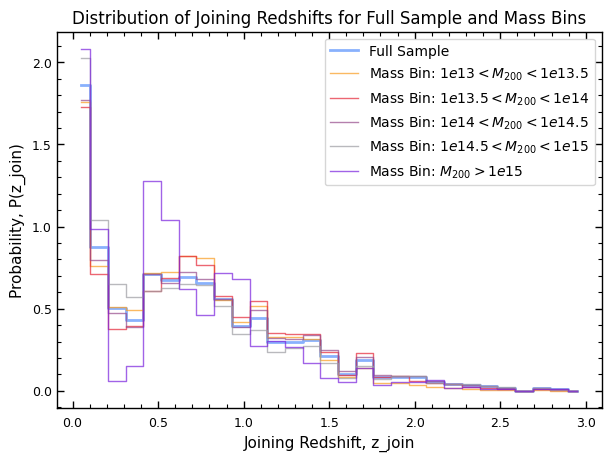

In [15]:
# plot the probability distribution for joining redshift of subhalos, excluding when its np.nan, and plot it across redshift for the full sample and for the 5 mass bins

galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
mass_bins = [
    galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
]
redshifts.append(snapshot[1])

# Full sample: accumulate joining redshifts from all mass bins
for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    for subhalo in group.getSatelliteSubhalos():
        # if not np.isnan(subhalo.getJoiningRedshift()):
        joiningRedshift = subhalo.getJoiningRedshift(numR200=numR200Join)
        joining_redshift_full_sample.append(joiningRedshift) if not np.isnan(joiningRedshift) else None

print(joining_redshift_full_sample)

# Mass bins: accumulate joining redshifts separately for each bin
for i, mass_bin in enumerate(mass_bins):
    for group in mass_bin.getAllGalaxyGroups():
        for subhalo in group.getSatelliteSubhalos():
            # if not np.isnan(subhalo.getJoiningRedshift()):
            # joining_redshift_info = subhalo.getJoiningRedshiftInfo()
            # arr = np.asarray(joining_redshift_info)
            # if not (arr.size == 1 and np.all(np.isnan(arr))):
            joiningRedshift = subhalo.getJoiningRedshift(numR200=numR200Join)
            joining_redshift_mass_bins[i].append(joiningRedshift) if not np.isnan(joiningRedshift) else None
# Now plot the distributions of joining redshifts for the full sample and mass bins across redshift
joiningRedshift_plotter = AstroPlotter()
joiningRedshift_fig, joiningRedshift_ax = joiningRedshift_plotter.create_figure()
# joiningRedshift_ax.hist(joining_redshift_full_sample, bins=30, alpha=alphaPrimary, label='Full Sample', histtype='step', density=True, linewidth=2)
# for i in range(len(mass_bin_labels)):
#     joiningRedshift_ax.hist(joining_redshift_mass_bins[i], bins=30, alpha=alphaSecondary, label=f'Mass Bin: {mass_bin_labels[i]}', histtype='step', density=True, linewidth=1)

joining_redshift_full_sample_bin_values, joining_redshift_full_sample_bin_centers, joining_redshift_full_sample_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_full_sample,
    bins=np.linspace(0, 3, 30),
    errorbarType='poisson',
    density=True,
)
joiningRedshift_plotter.scatter_plot(
    joining_redshift_full_sample_bin_centers,
    joining_redshift_full_sample_bin_values,
    # errorBars=joining_redshift_full_sample_bin_errorbars,
    label='Full Sample',
    drawstyle='steps-mid',
    linewidth=2,
    ax=joiningRedshift_ax,
)

for i in range(len(mass_bin_labels)):
    joining_redshift_bin_values, joining_redshift_bin_centers, joining_redshift_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
        joining_redshift_mass_bins[i],
        bins=np.linspace(0, 3, 30),
        errorbarType='poisson',
        density=True,
    )
    joiningRedshift_plotter.scatter_plot(
        joining_redshift_bin_centers,
        joining_redshift_bin_values,
        yerr=joining_redshift_bin_errorbars,
        label=f'Mass Bin: {mass_bin_labels[i]}',
        drawstyle='steps-mid',
        linewidth=1,
        ax=joiningRedshift_ax,
    )
joiningRedshift_ax.set_xlabel('Joining Redshift, z_join')
joiningRedshift_ax.set_ylabel('Probability, P(z_join)')
joiningRedshift_ax.set_title('Distribution of Joining Redshifts for Full Sample and Mass Bins')
joiningRedshift_ax.legend()
plt.show()

In [26]:
#print num of joining redshifts < 1.0 vs >= 1.0 for the full sample
joining_redshift_full_sample_check = np.array(joining_redshift_full_sample)
num_joining_redshift_lt1 = np.sum(joining_redshift_full_sample_check < 1.0)
num_joining_redshift_ge1 = np.sum(joining_redshift_full_sample_check >= 1.0)
print(f"Number of joining redshifts < 1.0: {num_joining_redshift_lt1}")
print(f"Number of joining redshifts >= 1.0: {num_joining_redshift_ge1}")

Number of joining redshifts < 1.0: 20259
Number of joining redshifts >= 1.0: 6412


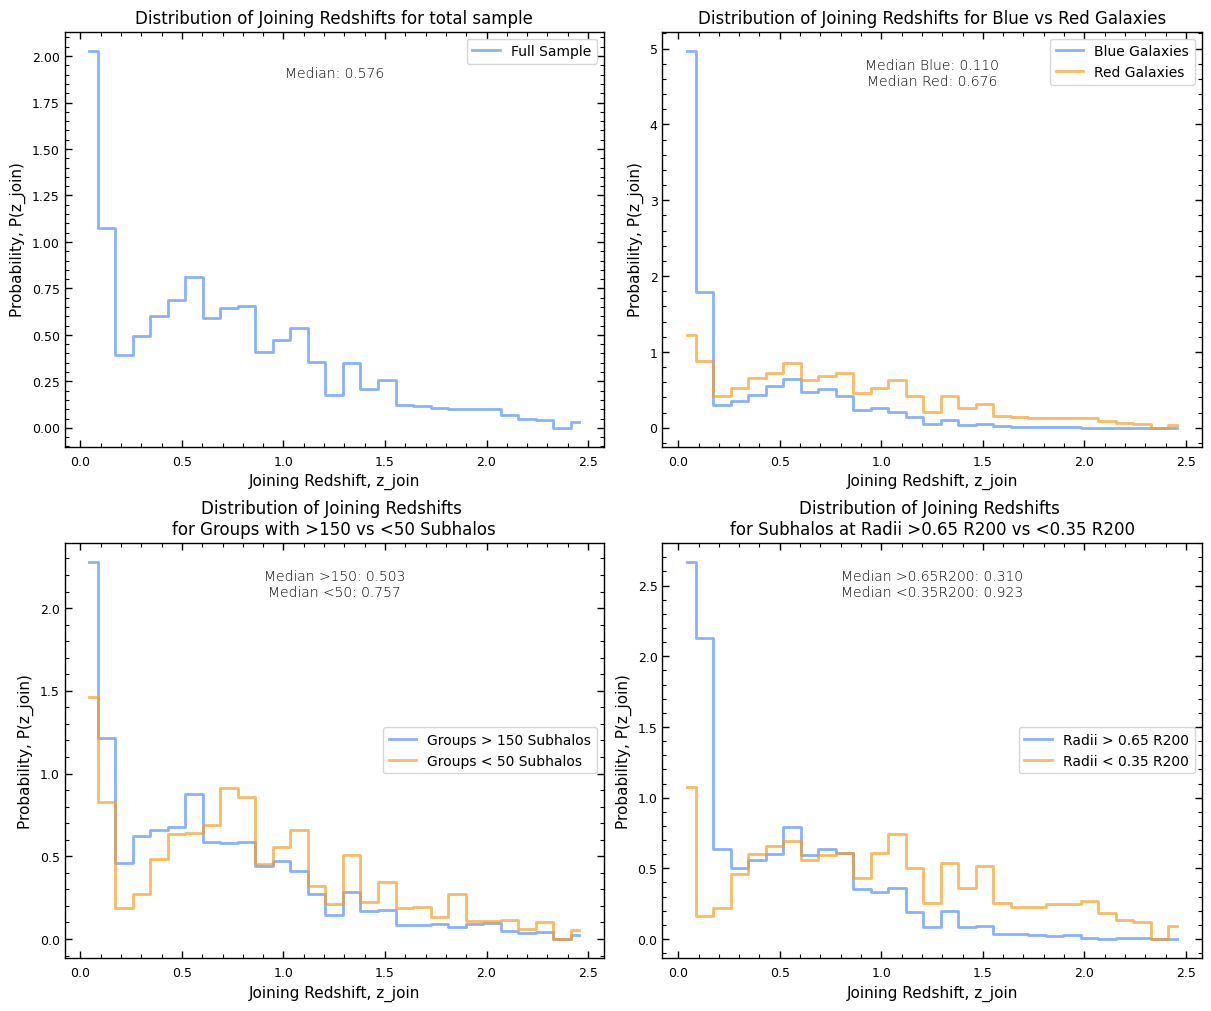

['/scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/joining_redshift_distribution_split_by_color_group_size_radius_TNG300-1.pdf',
 '/scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/joining_redshift_distribution_split_by_color_group_size_radius_TNG300-1.png']

In [16]:


#do same but separate for blue/red galaxys, group number > or < 150 or 50, and radius > 0.65R200 or < 0.35R200
joining_redshift_blue = []
joining_redshift_red = []
joining_redshift_group_gt150 = []
joining_redshift_group_lt50 = []
joining_redshift_radius_gt065 = []
joining_redshift_radius_lt035 = []

numR200Join=1

# for mass_bin in mass_bins:
#     for group in mass_bin.getAllGalaxyGroups():
for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    for subhalo in group.getSatelliteSubhalos():
        if not np.isnan(subhalo.getJoiningRedshift(numR200=numR200Join)):
            joiningRedshift = subhalo.getJoiningRedshift(numR200=numR200Join)
            if abs(subhalo.getGbandMagnitude() - subhalo.getRbandMagnitude()) < 0.65:
                joining_redshift_blue.append(joiningRedshift)
            else:
                joining_redshift_red.append(joiningRedshift)
            if len(group.getSatelliteSubhalos()) > 150:
                joining_redshift_group_gt150.append(joiningRedshift)
            elif len(group.getSatelliteSubhalos()) < 50:
                joining_redshift_group_lt50.append(joiningRedshift)
            if subhalo.getDistanceToGroupCenter() > 0.65 * group.getRCrit200():
                joining_redshift_radius_gt065.append(joiningRedshift)
            elif subhalo.getDistanceToGroupCenter() < 0.35 * group.getRCrit200():
                joining_redshift_radius_lt035.append(joiningRedshift)
                        
joiningRedshift_split_plotter = AstroPlotter()
joiningRedshift_split_fig, joiningRedshift_split_ax = joiningRedshift_split_plotter.create_figure(nrows=2, ncols=2, figsize=(12, 10))
bins_primary = np.linspace(0, 2.5, 30)
bins_secondary = np.linspace(0, 2.5, 30)
linewidthConst = 2

# joiningRedshift_split_ax[0, 0].hist(joining_redshift_full_sample, bins=bins_primary, alpha=alphaPrimary, label='Full Sample', histtype='step', density=True, linewidth=linewidthConst)
# joiningRedshift_split_ax[0, 1].hist(joining_redshift_blue, bins=bins_primary, alpha=alphaPrimary, label='Blue Galaxies', histtype='step', density=True, linewidth=linewidthConst)
# joiningRedshift_split_ax[0, 1].hist(joining_redshift_red, bins=bins_secondary, alpha=alphaSecondary, label='Red Galaxies', histtype='step', density=True, linewidth=linewidthConst)

# joiningRedshift_split_ax[1,0].hist(joining_redshift_group_gt150, bins=bins_primary, alpha=alphaPrimary, label='Groups > 150 Subhalos', histtype='step', density=True, linewidth=linewidthConst)
# joiningRedshift_split_ax[1,0].hist(joining_redshift_group_lt50, bins=bins_secondary, alpha=alphaSecondary, label='Groups < 50 Subhalos', histtype='step', density=True, linewidth=linewidthConst)

# joiningRedshift_split_ax[1,1].hist(joining_redshift_radius_gt065, bins=bins_primary, alpha=alphaPrimary, label='Radii > 0.65 R200', histtype='step', density=True, linewidth=linewidthConst)
# joiningRedshift_split_ax[1,1].hist(joining_redshift_radius_lt035, bins=bins_secondary, alpha=alphaSecondary, label='Radii < 0.35 R200', histtype='step', density=True, linewidth=linewidthConst)

useDensity=True
useNormalizeToOne = not useDensity

joining_redshift_full_sample_bin_values, joining_redshift_full_sample_bin_centers, joining_redshift_full_sample_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_full_sample,
    bins=bins_primary,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningRedshift_split_plotter.scatter_plot(
    joining_redshift_full_sample_bin_centers,
    joining_redshift_full_sample_bin_values,
    # errorBars=joining_redshift_full_sample_bin_errorbars,
    label='Full Sample',
    drawstyle='steps-mid',
    linewidth=linewidthConst,
    ax=joiningRedshift_split_ax[0, 0],
)


joining_redshift_blue_bin_values, joining_redshift_blue_bin_centers, joining_redshift_blue_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_blue,
    bins=bins_primary,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningRedshift_split_plotter.scatter_plot(
    joining_redshift_blue_bin_centers,
    joining_redshift_blue_bin_values,
    # errorBars=joining_redshift_blue_bin_errorbars,
    label='Blue Galaxies',
    drawstyle='steps-mid',
    linewidth=linewidthConst,
    ax=joiningRedshift_split_ax[0, 1],
)
joining_redshift_red_bin_values, joining_redshift_red_bin_centers, joining_redshift_red_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_red,
    bins=bins_secondary,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningRedshift_split_plotter.scatter_plot(
    joining_redshift_red_bin_centers,
    joining_redshift_red_bin_values,
    # errorBars=joining_redshift_red_bin_errorbars,
    label='Red Galaxies',
    drawstyle='steps-mid',
    linewidth=linewidthConst,
    ax=joiningRedshift_split_ax[0, 1],
)


joining_redshift_group_gt150_bin_values, joining_redshift_group_gt150_bin_centers, joining_redshift_group_gt150_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_group_gt150,
    bins=bins_primary,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningRedshift_split_plotter.scatter_plot(
    joining_redshift_group_gt150_bin_centers,
    joining_redshift_group_gt150_bin_values,
    # errorBars=joining_redshift_group_gt150_bin_errorbars,
    label='Groups > 150 Subhalos',
    drawstyle='steps-mid',
    linewidth=linewidthConst,
    ax=joiningRedshift_split_ax[1, 0],
)


joining_redshift_group_lt50_bin_values, joining_redshift_group_lt50_bin_centers, joining_redshift_group_lt50_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_group_lt50,
    bins=bins_secondary,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningRedshift_split_plotter.scatter_plot(
    joining_redshift_group_lt50_bin_centers,
    joining_redshift_group_lt50_bin_values,
    # errorBars=joining_redshift_group_lt50_bin_errorbars,
    label='Groups < 50 Subhalos',
    drawstyle='steps-mid',
    linewidth=linewidthConst,
    ax=joiningRedshift_split_ax[1, 0],
)



joining_redshift_radius_gt065_bin_values, joining_redshift_radius_gt065_bin_centers, joining_redshift_radius_gt065_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_radius_gt065,
    bins=bins_primary,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningRedshift_split_plotter.scatter_plot(
    joining_redshift_radius_gt065_bin_centers,
    joining_redshift_radius_gt065_bin_values,
    # errorBars=joining_redshift_radius_gt065_bin_errorbars,
    label='Radii > 0.65 R200',
    drawstyle='steps-mid',
    linewidth=linewidthConst,
    ax=joiningRedshift_split_ax[1, 1],
)
joining_redshift_radius_lt035_bin_values, joining_redshift_radius_lt035_bin_centers, joining_redshift_radius_lt035_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    joining_redshift_radius_lt035,
    bins=bins_secondary,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningRedshift_split_plotter.scatter_plot(
    joining_redshift_radius_lt035_bin_centers,
    joining_redshift_radius_lt035_bin_values,
    # errorBars=joining_redshift_radius_lt035_bin_errorbars,
    label='Radii < 0.35 R200',
    drawstyle='steps-mid',
    linewidth=linewidthConst,
    ax=joiningRedshift_split_ax[1, 1],
)



joiningRedshift_split_ax[0,  0].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[0,  0].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[0,  0].set_title('Distribution of Joining Redshifts for total sample')
joiningRedshift_split_ax[0,  0].legend()
joiningRedshift_split_ax[0,  1].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[0,  1].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[0, 1].set_title('Distribution of Joining Redshifts for Blue vs Red Galaxies')
joiningRedshift_split_ax[0, 1].legend()
joiningRedshift_split_ax[1,  0].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[1,  0].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[1,  0].set_title('Distribution of Joining Redshifts \nfor Groups with >150 vs <50 Subhalos')
joiningRedshift_split_ax[1,  0].legend()
joiningRedshift_split_ax[1,  1].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[1,  1].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[1,  1].set_title('Distribution of Joining Redshifts \nfor Subhalos at Radii >0.65 R200 vs <0.35 R200')
joiningRedshift_split_ax[1,  1].legend()


#put an anotationi in each panel saying the median joining redshift for each distribution
joiningRedshift_split_plotter.add_annotation(
    f'Median: {np.median(joining_redshift_full_sample):.3f}',
    ax=joiningRedshift_split_ax[0, 0],
    xy=(0.5, 0.9),
    xycoords='axes fraction',
    ha='center',
    va='center',
)

# print(np.where(np.isnan(joining_redshift_blue)))
joiningRedshift_split_plotter.add_annotation(
    f'Median Blue: {np.median(joining_redshift_blue):.3f}\nMedian Red: {np.median(joining_redshift_red):.3f}',
    ax=joiningRedshift_split_ax[0, 1],
    xy=(0.5, 0.9),
    xycoords='axes fraction',
    ha='center',
    va='center',
)

joiningRedshift_split_plotter.add_annotation(
    f'Median >150: {np.median(joining_redshift_group_gt150):.3f}\nMedian <50: {np.median(joining_redshift_group_lt50):.3f}',
    ax=joiningRedshift_split_ax[1, 0],
    xy=(0.5, 0.9),
    xycoords='axes fraction',
    ha='center',
    va='center',
)

joiningRedshift_split_plotter.add_annotation(
    f'Median >0.65R200: {np.median(joining_redshift_radius_gt065):.3f}\nMedian <0.35R200: {np.median(joining_redshift_radius_lt035):.3f}',
    ax=joiningRedshift_split_ax[1, 1],
    xy=(0.5, 0.9),
    xycoords='axes fraction',
    ha='center',
    va='center',
)

#make sure fig shows:
plt.show()

joiningRedshift_split_plotter.save_figure(
    joiningRedshift_split_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/joining_redshift_distribution_split_by_color_group_size_radius_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

### joining together redshift

In [7]:
#plot the fraction of galaxies in which have the subhalos in the same group have the same joining redshift (i.e. they joined together) for each grouping number of same joining redshift for the full sample and mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

numR200Join = 1

snapshot = SnapshotEnum.SNAPSHOT_99.value
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
mass_bins = [
    galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
]
dic_all_groups_joining_redshifts : dict[int, dict[float, list[int]]] = {} # key: groupID, value: dict where key is joining redshift and value is list of subhalo IDs with that joining redshift in that group
dic_mass_groups_joining_redshifts : dict[str, dict[int, dict[float, list[int]]]] = {} # key: mass bin label, value: dict where key is groupID and value is dict where key is joining redshift and value is list of subhalo IDs with that joining redshift in that group

for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    dic_group_joining_redshifts : dict[float, list[int]] = {} # key: joining redshift, value: list of subhalo IDs with that joining redshift
    for subhalo in group.getSatelliteSubhalos():
        if not np.isnan(subhalo.getJoiningRedshift(numR200=numR200Join)):
            joining_redshift = subhalo.getJoiningRedshift(numR200=numR200Join)
            if joining_redshift not in dic_group_joining_redshifts:
                # if joining_redshift < 2:
                #     print(f"Group {group.getGroupID()} has subhalo {subhalo.getIdx()} with joining redshift {joining_redshift}")
                dic_group_joining_redshifts[joining_redshift] = []
            dic_group_joining_redshifts[joining_redshift].append(subhalo.getIdx())
    
    if group.getMCrit200() > 1e14:
        dic_all_groups_joining_redshifts[group.getGroupID()] = dic_group_joining_redshifts
    if group.getMCrit200() > 1e13 and group.getMCrit200() < 10**13.5:
        mass_bin_label = mass_bin_labels[0]
    elif group.getMCrit200() > 10**13.5 and group.getMCrit200() < 1e14:
        mass_bin_label = mass_bin_labels[1]
    elif group.getMCrit200() > 1e14 and group.getMCrit200() < 10**14.5:
        mass_bin_label = mass_bin_labels[2]
    elif group.getMCrit200() > 10**14.5 and group.getMCrit200() < 1e15:
        mass_bin_label = mass_bin_labels[3]
    elif group.getMCrit200() > 1e15:
        mass_bin_label = mass_bin_labels[4]
    else:
        continue # skip groups that don't fall into any mass bin (shouldn't be any)
    if mass_bin_label not in dic_mass_groups_joining_redshifts:
        dic_mass_groups_joining_redshifts[mass_bin_label] = {}
    dic_mass_groups_joining_redshifts[mass_bin_label][group.getGroupID()] = dic_group_joining_redshifts

groupIDs_full_sample_joining_together = []
for groupID, joining_redshift_dict in dic_all_groups_joining_redshifts.items():
    for joining_redshift, subhaloIDs in joining_redshift_dict.items():
        # if len(subhaloIDs) > 1:
        groupIDs_full_sample_joining_together.append(len(subhaloIDs))
            # break # only need to count each group once, so break after finding the first joining redshift with >1 subhalo


print(f"len gg: {len(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f"len keys: {len(dic_all_groups_joining_redshifts.keys())}")


len gg: 280
len keys: 280


In [8]:
#plot the fraction of galaxies in which have the subhalos in the same group have the same joining redshift (i.e. they joined together) for each grouping number of same joining redshift for the full sample and mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

numR200Join = 1

snapshot = SnapshotEnum.SNAPSHOT_99.value
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
mass_bins = [
    galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
]
dic_all_groups_joining_redshifts : dict[int, dict[float, list[int]]] = {} # key: groupID, value: dict where key is joining redshift and value is list of subhalo IDs with that joining redshift in that group
dic_mass_groups_joining_redshifts : dict[str, dict[int, dict[float, list[int]]]] = {} # key: mass bin label, value: dict where key is groupID and value is dict where key is joining redshift and value is list of subhalo IDs with that joining redshift in that group

#do the same but split by blue/red galaxies, group number > or < 150 or 50, and radius > 0.65R200 or < 0.35R200
dic_red_blue_groups_joining_redshifts : dict[str, dict[int, dict[float, list[int]]]] = {} # key: 'blue' or 'red', value: dict where key is groupID and value is dict where key is joining redshift and value is list of subhalo IDs (that are red or blue respectively) with that joining redshift in that group
dic_gt150_lt50_members_groups_joining_redshifts : dict[str, dict[int, dict[float, list[int]]]] = {} # key: 'gt150' or 'lt50', value: dict where key is groupID and value is dict where key is joining redshift and value is list of subhalo IDs (that are gt150 or lt50 respectively) with that joining redshift in that group
dic_radius_gt0p65_lt0p35_groups_joining_redshifts : dict[str, dict[int, dict[float, list[int]]]] = {} # key: 'gt065' or 'lt035', value: dict where key is groupID and value is dict where key is joining redshift and value is list of subhalo IDs (that are gt065 or lt035 respectively) with that joining redshift in that group

for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    dic_group_joining_redshifts : dict[float, list[int]] = {} # key: joining redshift, value: list of subhalo IDs with that joining redshift
    for subhalo in group.getSatelliteSubhalos():
        if not np.isnan(subhalo.getJoiningRedshift(numR200=numR200Join)):
            joining_redshift = subhalo.getJoiningRedshift(numR200=numR200Join)
            if joining_redshift not in dic_group_joining_redshifts:
                # if joining_redshift < 2:
                #     print(f"Group {group.getGroupID()} has subhalo {subhalo.getIdx()} with joining redshift {joining_redshift}")
                dic_group_joining_redshifts[joining_redshift] = []
            dic_group_joining_redshifts[joining_redshift].append(subhalo.getIdx())

            if abs(subhalo.getGbandMagnitude() - subhalo.getRbandMagnitude()) < 0.65:
                if 'blue' not in dic_red_blue_groups_joining_redshifts:
                    dic_red_blue_groups_joining_redshifts['blue'] = {}
                if group.getGroupID() not in dic_red_blue_groups_joining_redshifts['blue']:
                    dic_red_blue_groups_joining_redshifts['blue'][group.getGroupID()] = {}
                if joining_redshift not in dic_red_blue_groups_joining_redshifts['blue'][group.getGroupID()]:
                    dic_red_blue_groups_joining_redshifts['blue'][group.getGroupID()][joining_redshift] = []
                dic_red_blue_groups_joining_redshifts['blue'][group.getGroupID()][joining_redshift].append(subhalo.getIdx())
            else:                
                if 'red' not in dic_red_blue_groups_joining_redshifts:
                    dic_red_blue_groups_joining_redshifts['red'] = {}
                if group.getGroupID() not in dic_red_blue_groups_joining_redshifts['red']:
                    dic_red_blue_groups_joining_redshifts['red'][group.getGroupID()] = {}
                if joining_redshift not in dic_red_blue_groups_joining_redshifts['red'][group.getGroupID()]:
                    dic_red_blue_groups_joining_redshifts['red'][group.getGroupID()][joining_redshift] = []
                dic_red_blue_groups_joining_redshifts['red'][group.getGroupID()][joining_redshift].append(subhalo.getIdx())
                
            if len(group.getSatelliteSubhalos()) > 150:
                if 'gt150' not in dic_gt150_lt50_members_groups_joining_redshifts:
                    dic_gt150_lt50_members_groups_joining_redshifts['gt150'] = {}
                if group.getGroupID() not in dic_gt150_lt50_members_groups_joining_redshifts['gt150']:
                    dic_gt150_lt50_members_groups_joining_redshifts['gt150'][group.getGroupID()] = {}
                if joining_redshift not in dic_gt150_lt50_members_groups_joining_redshifts['gt150'][group.getGroupID()]:
                    dic_gt150_lt50_members_groups_joining_redshifts['gt150'][group.getGroupID()][joining_redshift] = []
                dic_gt150_lt50_members_groups_joining_redshifts['gt150'][group.getGroupID()][joining_redshift].append(subhalo.getIdx())
            elif len(group.getSatelliteSubhalos()) < 50:
                if 'lt50' not in dic_gt150_lt50_members_groups_joining_redshifts:
                    dic_gt150_lt50_members_groups_joining_redshifts['lt50'] = {}
                if group.getGroupID() not in dic_gt150_lt50_members_groups_joining_redshifts['lt50']:
                    dic_gt150_lt50_members_groups_joining_redshifts['lt50'][group.getGroupID()] = {}
                if joining_redshift not in dic_gt150_lt50_members_groups_joining_redshifts['lt50'][group.getGroupID()]:
                    dic_gt150_lt50_members_groups_joining_redshifts['lt50'][group.getGroupID()][joining_redshift] = []
                dic_gt150_lt50_members_groups_joining_redshifts['lt50'][group.getGroupID()][joining_redshift].append(subhalo.getIdx())
            if subhalo.getDistanceToGroupCenter() > 0.65 * group.getRCrit200():
                if 'gt065' not in dic_radius_gt0p65_lt0p35_groups_joining_redshifts:
                    dic_radius_gt0p65_lt0p35_groups_joining_redshifts['gt065'] = {}
                if group.getGroupID() not in dic_radius_gt0p65_lt0p35_groups_joining_redshifts['gt065']:
                    dic_radius_gt0p65_lt0p35_groups_joining_redshifts['gt065'][group.getGroupID()] = {}
                if joining_redshift not in dic_radius_gt0p65_lt0p35_groups_joining_redshifts['gt065'][group.getGroupID()]:
                    dic_radius_gt0p65_lt0p35_groups_joining_redshifts['gt065'][group.getGroupID()][joining_redshift] = []
                dic_radius_gt0p65_lt0p35_groups_joining_redshifts['gt065'][group.getGroupID()][joining_redshift].append(subhalo.getIdx())
            elif subhalo.getDistanceToGroupCenter() < 0.35 * group.getRCrit200():
                if 'lt035' not in dic_radius_gt0p65_lt0p35_groups_joining_redshifts:
                    dic_radius_gt0p65_lt0p35_groups_joining_redshifts['lt035'] = {}
                if group.getGroupID() not in dic_radius_gt0p65_lt0p35_groups_joining_redshifts['lt035']:
                    dic_radius_gt0p65_lt0p35_groups_joining_redshifts['lt035'][group.getGroupID()] = {}
                if joining_redshift not in dic_radius_gt0p65_lt0p35_groups_joining_redshifts['lt035'][group.getGroupID()]:
                    dic_radius_gt0p65_lt0p35_groups_joining_redshifts['lt035'][group.getGroupID()][joining_redshift] = []
                dic_radius_gt0p65_lt0p35_groups_joining_redshifts['lt035'][group.getGroupID()][joining_redshift].append(subhalo.getIdx())
    
    if group.getMCrit200() > 1e14:
        dic_all_groups_joining_redshifts[group.getGroupID()] = dic_group_joining_redshifts
    if group.getMCrit200() > 1e13 and group.getMCrit200() < 10**13.5:
        mass_bin_label = mass_bin_labels[0]
    elif group.getMCrit200() > 10**13.5 and group.getMCrit200() < 1e14:
        mass_bin_label = mass_bin_labels[1]
    elif group.getMCrit200() > 1e14 and group.getMCrit200() < 10**14.5:
        mass_bin_label = mass_bin_labels[2]
    elif group.getMCrit200() > 10**14.5 and group.getMCrit200() < 1e15:
        mass_bin_label = mass_bin_labels[3]
    elif group.getMCrit200() > 1e15:
        mass_bin_label = mass_bin_labels[4]
    else:
        continue # skip groups that don't fall into any mass bin (shouldn't be any)
    if mass_bin_label not in dic_mass_groups_joining_redshifts:
        dic_mass_groups_joining_redshifts[mass_bin_label] = {}
    dic_mass_groups_joining_redshifts[mass_bin_label][group.getGroupID()] = dic_group_joining_redshifts

groupIDs_full_sample_joining_together = []
for groupID, joining_redshift_dict in dic_all_groups_joining_redshifts.items():
    for joining_redshift, subhaloIDs in joining_redshift_dict.items():
        # if len(subhaloIDs) > 1:
        groupIDs_full_sample_joining_together.append(len(subhaloIDs))
            # break # only need to count each group once, so break after finding the first joining redshift with >1 subhalo







### plot identical z_j

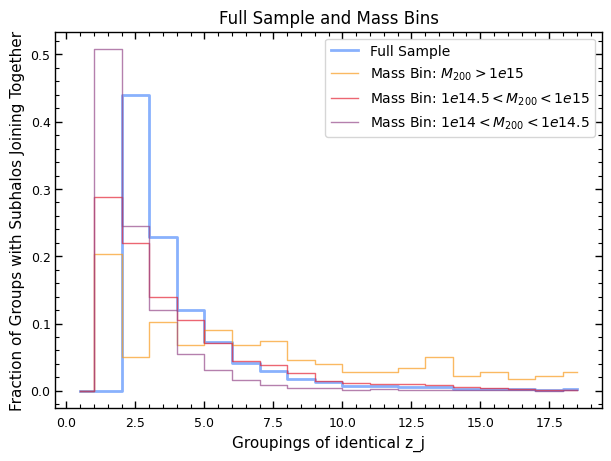

In [39]:
bins = np.arange(0, 20, 1) # bins for number of subhalos joining together (i.e. with same joining redshift)

useDensity=True
useNormalizeToOne = not useDensity

joiningTogether_plotter = AstroPlotter()
joiningTogether_fig, joiningTogether_ax = joiningTogether_plotter.create_figure()

joining_together_full_sample_bin_values, joining_together_full_sample_bin_centers, joining_together_full_sample_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    groupIDs_full_sample_joining_together,
    bins=bins,
    errorbarType='poisson',
    density=useDensity,
    normalize_to_one=useNormalizeToOne,
)
joiningTogether_plotter.scatter_plot(
    joining_together_full_sample_bin_centers,
    joining_together_full_sample_bin_values,
    # errorBars=joining_together_full_sample_bin_errorbars,
    label='Full Sample',
    drawstyle='steps-mid',
    linewidth=2,
    ax=joiningTogether_ax,
)
groupIDs_mass_bins_joining_together : dict[str, list[int]] = {} # key: mass bin label, value: list of number of subhalos joining together for groups in that mass bin
# for mass_bin_label, groups_joining_redshifts in dic_mass_groups_joining_redshifts.items():
#     groupIDs_mass_bins_joining_together[mass_bin_label] = []
#     for groupID, joining_redshift_dict in groups_joining_redshifts.items():
#         for joining_redshift, subhaloIDs in joining_redshift_dict.items():
#             # if len(subhaloIDs) > 1:
#             groupIDs_mass_bins_joining_together[mass_bin_label].append(len(subhaloIDs))
#             # continue # only need to count each group once, so break after finding the first joining redshift with >1 subhalo
# for i in range(len(mass_bin_labels)):
#     if mass_bin_labels[i] in groupIDs_mass_bins_joining_together:
#         joiningTogether_ax.hist(
#             groupIDs_mass_bins_joining_together[mass_bin_labels[i]],
#             bins=bins,
#             alpha=alphaSecondary,
#             label=f'Mass Bin: {mass_bin_labels[i]}',
#             histtype='step',
#             weights=np.ones_like(groupIDs_mass_bins_joining_together[mass_bin_labels[i]]) / len(groupIDs_mass_bins_joining_together[mass_bin_labels[i]]),
#             linewidth=1
#         )

for mass_bin_label, groups_joining_redshifts in dic_mass_groups_joining_redshifts.items():
    groupIDs_mass_bins_joining_together[mass_bin_label] = []
    for groupID, joining_redshift_dict in groups_joining_redshifts.items():
        for joining_redshift, subhaloIDs in joining_redshift_dict.items():
            # if len(subhaloIDs) > 1:
            groupIDs_mass_bins_joining_together[mass_bin_label].append(len(subhaloIDs))
            # continue # only need to count each group once, so break after finding the first joining redshift with >1 subhalo
    if mass_bin_label in groupIDs_mass_bins_joining_together:
        joining_together_bin_values, joining_together_bin_centers, joining_together_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
            groupIDs_mass_bins_joining_together[mass_bin_label],
            bins=bins,
            errorbarType='poisson',
            density=useDensity,
            normalize_to_one=useNormalizeToOne,
        )
        joiningTogether_plotter.scatter_plot(
            joining_together_bin_centers,
            joining_together_bin_values,
            # errorBars=joining_together_bin_errorbars,
            label=f'Mass Bin: {mass_bin_label}',
            drawstyle='steps-mid',
            linewidth=1,
            ax=joiningTogether_ax,
        )
joiningTogether_ax.set_xlabel('Groupings of identical z_j')
joiningTogether_ax.set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_ax.set_title('Full Sample and Mass Bins')
joiningTogether_ax.legend()
joiningTogether_plotter.save_figure(
    joiningTogether_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/fraction_joining_together_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)
plt.show()

Processing color category: red
Processing color category: blue


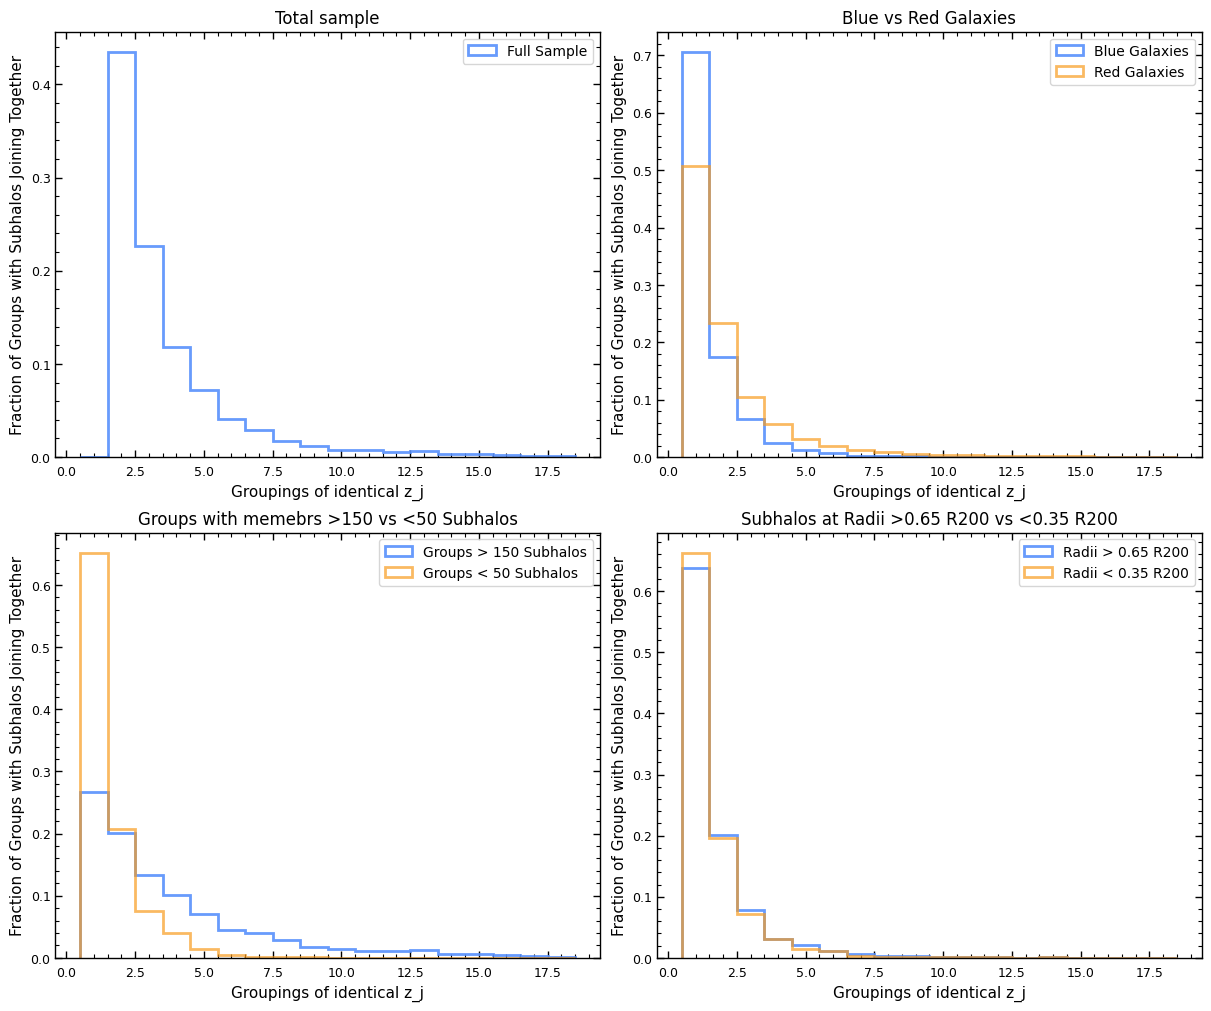

In [40]:
groupIDs_red_blue_joining_together : dict[str, list[int]] = {} # key: 'blue' or 'red', value: list of number of subhalos joining together for groups in that color category
for color_category, groups_joining_redshifts in dic_red_blue_groups_joining_redshifts.items():
    print(f"Processing color category: {color_category}")
    groupIDs_red_blue_joining_together[color_category] = []
    for groupID, joining_redshift_dict in groups_joining_redshifts.items():
        for joining_redshift, subhaloIDs in joining_redshift_dict.items():
            # if len(subhaloIDs) > 1:
            groupIDs_red_blue_joining_together[color_category].append(len(subhaloIDs))
                # break # only need to count each group once, so break after finding the first joining redshift with >1 subhalo
groupIDs_gt150_lt50_joining_together : dict[str, list[int]] = {} # key: 'gt150' or 'lt50', value: list of number of subhalos joining together for groups in that category
for size_category, groups_joining_redshifts in dic_gt150_lt50_members_groups_joining_redshifts.items():
    groupIDs_gt150_lt50_joining_together[size_category] = []
    for groupID, joining_redshift_dict in groups_joining_redshifts.items():
        for joining_redshift, subhaloIDs in joining_redshift_dict.items():
            # if len(subhaloIDs) > 1:
            groupIDs_gt150_lt50_joining_together[size_category].append(len(subhaloIDs))
                # break # only need to count each group once, so break after finding the first joining redshift with >1 subhalo
groupIDs_radius_gt0p65_lt0p35_joining_together : dict[str, list[int]] = {} # key: 'gt065' or 'lt035', value: list of number of subhalos joining together for groups in that category
for radius_category, groups_joining_redshifts in dic_radius_gt0p65_lt0p35_groups_joining_redshifts.items():
    groupIDs_radius_gt0p65_lt0p35_joining_together[radius_category] = []
    for groupID, joining_redshift_dict in groups_joining_redshifts.items():
        for joining_redshift, subhaloIDs in joining_redshift_dict.items():
            # if len(subhaloIDs) > 1:
            groupIDs_radius_gt0p65_lt0p35_joining_together[radius_category].append(len(subhaloIDs))
                # break # only need to count each group once, so break after finding the first joining redshift with >1 subhalo

joiningTogether_split_plotter = AstroPlotter()
joiningTogether_split_fig, joiningTogether_split_ax = joiningTogether_split_plotter.create_figure(nrows=2, ncols=2, figsize=(12, 10))
bins = np.arange(0, 20, 1)
bin_centers = np.array((bins[:-1] + bins[1:]) / 2)
linewidthConst = 2
joiningTogether_split_ax[0, 0].hist(
    groupIDs_full_sample_joining_together,
    bins=bin_centers,
    alpha=alphaPrimary,
    label='Full Sample',
    histtype='step',
    weights=np.ones_like(groupIDs_full_sample_joining_together) / len(groupIDs_full_sample_joining_together),
    linewidth=linewidthConst
)
joiningTogether_split_ax[0, 1].hist(
    groupIDs_red_blue_joining_together['blue'],
    bins=bin_centers,
    alpha=alphaPrimary,
    label='Blue Galaxies',
    histtype='step',
    weights=np.ones_like(groupIDs_red_blue_joining_together['blue']) / len(groupIDs_red_blue_joining_together['blue']),
    linewidth=linewidthConst
)
joiningTogether_split_ax[0, 1].hist(
    groupIDs_red_blue_joining_together['red'],
    bins=bin_centers,
    alpha=alphaSecondary,
    label='Red Galaxies',
    histtype='step',
    weights=np.ones_like(groupIDs_red_blue_joining_together['red']) / len(groupIDs_red_blue_joining_together['red']),
    linewidth=linewidthConst
)
joiningTogether_split_ax[1, 0].hist(
    groupIDs_gt150_lt50_joining_together['gt150'],
    bins=bin_centers,
    alpha=alphaPrimary,
    label='Groups > 150 Subhalos',
    histtype='step',
    weights=np.ones_like(groupIDs_gt150_lt50_joining_together['gt150']) / len(groupIDs_gt150_lt50_joining_together['gt150']),
    linewidth=linewidthConst
)
joiningTogether_split_ax[1, 0].hist(
    groupIDs_gt150_lt50_joining_together['lt50'],
    bins=bin_centers,
    alpha=alphaSecondary,
    label='Groups < 50 Subhalos',
    histtype='step',
    weights=np.ones_like(groupIDs_gt150_lt50_joining_together['lt50']) / len(groupIDs_gt150_lt50_joining_together['lt50']),
    linewidth=linewidthConst
)
joiningTogether_split_ax[1, 1].hist(
    groupIDs_radius_gt0p65_lt0p35_joining_together['gt065'],
    bins=bin_centers,
    alpha=alphaPrimary,
    label='Radii > 0.65 R200',
    histtype='step',
    weights=np.ones_like(groupIDs_radius_gt0p65_lt0p35_joining_together['gt065']) / len(groupIDs_radius_gt0p65_lt0p35_joining_together['gt065']),
    linewidth=linewidthConst
)
joiningTogether_split_ax[1, 1].hist(
    groupIDs_radius_gt0p65_lt0p35_joining_together['lt035'],
    bins=bin_centers,
    alpha=alphaSecondary,
    label='Radii < 0.35 R200',
    histtype='step',
    weights=np.ones_like(groupIDs_radius_gt0p65_lt0p35_joining_together['lt035']) / len(groupIDs_radius_gt0p65_lt0p35_joining_together['lt035']),
    linewidth=linewidthConst
)
joiningTogether_split_ax[0, 0].set_xlabel('Groupings of identical z_j')
joiningTogether_split_ax[0, 0].set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_split_ax[0, 0].set_title('Total sample')
joiningTogether_split_ax[0, 0].legend()
joiningTogether_split_ax[0, 1].set_xlabel('Groupings of identical z_j')
joiningTogether_split_ax[0, 1].set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_split_ax[0, 1].set_title('Blue vs Red Galaxies')
joiningTogether_split_ax[0, 1].legend()
joiningTogether_split_ax[1, 0].set_xlabel('Groupings of identical z_j')
joiningTogether_split_ax[1, 0].set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_split_ax[1, 0].set_title('Groups with memebrs >150 vs <50 Subhalos')
joiningTogether_split_ax[1, 0].legend()
joiningTogether_split_ax[1, 1].set_xlabel('Groupings of identical z_j')
joiningTogether_split_ax[1, 1].set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_split_ax[1, 1].set_title('Subhalos at Radii >0.65 R200 vs <0.35 R200')
joiningTogether_split_ax[1, 1].legend()
joiningTogether_split_plotter.save_figure(
    joiningTogether_split_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/fraction_joining_together_split_by_color_group_size_radius_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

plt.show()

### split by identical z_j

In [9]:
#check the list of joining redshift keys in dic_all_groups_joining_redshifts
joining_redshift_keys = [] #duplicates allowed across different groups, but not within the same group since joining redshift is a property of the subhalo and should be the same for all subhalos that joined together
for groupID, joining_redshift_dict in dic_all_groups_joining_redshifts.items():
    for joining_redshift in joining_redshift_dict.keys():
        joining_redshift_keys.append(joining_redshift)
            
print(f"Total number of unique joining redshift keys across all groups: {len(joining_redshift_keys)}")
print(f"num z_j <= 1: {len([z for z in joining_redshift_keys if z <= 1])}")
print(f"num z_j > 1: {len([z for z in joining_redshift_keys if z > 1])}")

Total number of unique joining redshift keys across all groups: 10359
num z_j <= 1: 7215
num z_j > 1: 3144


In [8]:
#plot the regular polar pairwise difference but separate between galaxies that joined together vs those that didn't (i.e. have same joining redshift vs different joining redshifts) compared to the full sample. And also separate galaxies with joining redshift < 1.0 vs > 1.0
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.utilities.GalaxyGroup import GalaxyGroup
polarDifference_joiningTogether = []
polarDifference_joiningTogether_err = []
polarDifference_notJoiningTogether = []
polarDifference_notJoiningTogether_err = []
polarDifference_joiningRedshiftLt1 = []
polarDifference_joiningRedshiftLt1_err = []
polarDifference_joiningRedshiftGt1 = []
polarDifference_joiningRedshiftGt1_err = []

# dic_all_groups_joining_redshifts is a dict where key is groupID and value is a dict where key is joining redshift and value is list of subhalo IDs with that joining redshift in that group. So for each group, we can loop through the joining redshifts and subhalo IDs to separate the subhalos into those that joined together (i.e. have same joining redshift) and those that didn't join together (i.e. have different joining redshifts), and then use those to create GalaxyGroup objects for each category, which we can then add to ListGalaxyGroup objects for each category, and then use those ListGalaxyGroup objects to calculate the polar pairwise difference for each category.



# from dic_all_groups_joining_redshifts, build a ListGalaxyGroup for the subhalos that joined together (i.e. have same joining redshift) and a ListGalaxyGroup for the subhalos that didn't join together (i.e. have different joining redshifts), then use those ListGalaxyGroups to calculate the polar pairwise difference for those two categories of galaxies
list_joiningTogether = ListGalaxyGroup()
list_notJoiningTogether = ListGalaxyGroup()
list_joiningRedshiftLt1 = ListGalaxyGroup()
list_joiningRedshiftGt1 = ListGalaxyGroup()
for groupID, joining_redshift_dict in dic_all_groups_joining_redshifts.items():
    originalgalaxyGroupid = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(groupID)
    
    temp_subhalos_to_add_to_not_joining_together = []
    temp_subhalos_to_add_lt1 = []
    temp_subhalos_to_add_gt1 = []
    
    for joining_redshift, listSubhaloIDs in joining_redshift_dict.items():
        galaxygroupJoiningTogether = GalaxyGroup(
            group_id=originalgalaxyGroupid.getGroupID(),
            MCrit200=originalgalaxyGroupid.getMCrit200(),
            RCrit200=originalgalaxyGroupid.getRCrit200(),
            pos =originalgalaxyGroupid.getPos(),
            posCM =originalgalaxyGroupid.getPosCM(),
            listSubhalos = None
        )
        galaxygroupNotJoiningTogether = GalaxyGroup(
            group_id=originalgalaxyGroupid.getGroupID(),
            MCrit200=originalgalaxyGroupid.getMCrit200(),
            RCrit200=originalgalaxyGroupid.getRCrit200(),
            pos =originalgalaxyGroupid.getPos(),
            posCM =originalgalaxyGroupid.getPosCM(),
            listSubhalos = None
        )
        galaxygroupLt1 = GalaxyGroup(
            group_id=originalgalaxyGroupid.getGroupID(),
            MCrit200=originalgalaxyGroupid.getMCrit200(),
            RCrit200=originalgalaxyGroupid.getRCrit200(),
            pos =originalgalaxyGroupid.getPos(),
            posCM =originalgalaxyGroupid.getPosCM(),
            listSubhalos = None
        )
        galaxygroupGt1 = GalaxyGroup(
            group_id=originalgalaxyGroupid.getGroupID(),
            MCrit200=originalgalaxyGroupid.getMCrit200(),
            RCrit200=originalgalaxyGroupid.getRCrit200(),
            pos =originalgalaxyGroupid.getPos(),
            posCM =originalgalaxyGroupid.getPosCM(),
            listSubhalos = None
        )

        temp_subhalos_to_add_to_joining_together = []

        #add central subhalo to both joining together and not joining together since it doesn't have a joining redshift and we want to include it in both categories for the polar pairwise difference calculation
        central_subhalo = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(groupID).getCentralSubhalo()
        temp_subhalos_to_add_to_joining_together.append(central_subhalo)
        temp_subhalos_to_add_to_not_joining_together.append(central_subhalo)
        temp_subhalos_to_add_lt1.append(central_subhalo)
        temp_subhalos_to_add_gt1.append(central_subhalo)
    

        for subhaloID in listSubhaloIDs:
            subhalo = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getSubhaloByID(subhaloID)
            if len(listSubhaloIDs) > 1:
                temp_subhalos_to_add_to_joining_together.append(subhalo)
                
                if joining_redshift < 1.0:
                    temp_subhalos_to_add_lt1.append(subhalo)
                else:
                    temp_subhalos_to_add_gt1.append(subhalo)
            else:
                temp_subhalos_to_add_to_not_joining_together.append(subhalo)


        galaxygroupJoiningTogether.setSubhaloList(temp_subhalos_to_add_to_joining_together)
        if len(galaxygroupJoiningTogether.getSatelliteSubhalos()) > 0:
            list_joiningTogether.addGalaxyGroup(galaxygroupJoiningTogether)

    galaxygroupLt1.setSubhaloList(temp_subhalos_to_add_lt1)
    galaxygroupGt1.setSubhaloList(temp_subhalos_to_add_gt1)
    if len(galaxygroupLt1.getSatelliteSubhalos()) > 0:
        list_joiningRedshiftLt1.addGalaxyGroup(galaxygroupLt1)
    if len(galaxygroupGt1.getSatelliteSubhalos()) > 0:
        list_joiningRedshiftGt1.addGalaxyGroup(galaxygroupGt1)

    galaxygroupNotJoiningTogether.setSubhaloList(temp_subhalos_to_add_to_not_joining_together)
    if len(galaxygroupNotJoiningTogether.getSatelliteSubhalos()) > 0:
        list_notJoiningTogether.addGalaxyGroup(galaxygroupNotJoiningTogether)


In [23]:
# sanity check - better diagnostics
print(f"Total groups in gt14 list: {len(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f"Groups with joining redshift info: {len(dic_all_groups_joining_redshifts)}")
print()
print("=== Group counts in each output list ===")
print(f"Groups in list_joiningTogether: {len(list_joiningTogether.getAllGalaxyGroups())}")
print(f"Groups in list_notJoiningTogether: {len(list_notJoiningTogether.getAllGalaxyGroups())}")
print(f"Groups in list_joiningRedshiftLt1: {len(list_joiningRedshiftLt1.getAllGalaxyGroups())}")
print(f"Groups in list_joiningRedshiftGt1: {len(list_joiningRedshiftGt1.getAllGalaxyGroups())}")
print()
print("=== Subhalo counts in each output list ===")
subhalos_gt14 = sum([len(group.getSatelliteSubhalos()) for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()])
print(f"Total subhalos in gt14 list: {subhalos_gt14}")
subhalos_joining = sum([len(group.getSatelliteSubhalos()) for group in list_joiningTogether.getAllGalaxyGroups()])
subhalos_not_joining = sum([len(group.getSatelliteSubhalos()) for group in list_notJoiningTogether.getAllGalaxyGroups()])
subhalos_lt1 = sum([len(group.getSatelliteSubhalos()) for group in list_joiningRedshiftLt1.getAllGalaxyGroups()])
subhalos_gt1 = sum([len(group.getSatelliteSubhalos()) for group in list_joiningRedshiftGt1.getAllGalaxyGroups()])

print(f"Total subhalos in joining together: {subhalos_joining}")
print(f"Total subhalos in not joining together: {subhalos_not_joining}")
print(f"Total subhalos in joining redshift < 1: {subhalos_lt1}")
print(f"Total subhalos in joining redshift > 1: {subhalos_gt1}")
print(f"Total across both analyses: {subhalos_joining + subhalos_not_joining} / {subhalos_lt1 + subhalos_gt1}")
print()
print("=== Overlap check ===")
# Check which groups appear in which lists
groups_joining = set([g.getGroupID() for g in list_joiningTogether.getAllGalaxyGroups()])
groups_not_joining = set([g.getGroupID() for g in list_notJoiningTogether.getAllGalaxyGroups()])
groups_lt1 = set([g.getGroupID() for g in list_joiningRedshiftLt1.getAllGalaxyGroups()])
groups_gt1 = set([g.getGroupID() for g in list_joiningRedshiftGt1.getAllGalaxyGroups()])

print(f"Groups in BOTH joining AND not_joining: {len(groups_joining & groups_not_joining)}")
print(f"Groups in BOTH Lt1 AND Gt1: {len(groups_lt1 & groups_gt1)}")
print(f"Groups in joining only: {len(groups_joining - groups_not_joining)}")
print(f"Groups in not_joining only: {len(groups_not_joining - groups_joining)}")
print(f"Groups in Lt1 only: {len(groups_lt1 - groups_gt1)}")
print(f"Groups in Gt1 only: {len(groups_gt1 - groups_lt1)}")

Total groups in gt14 list: 280
Groups with joining redshift info: 280

=== Group counts in each output list ===
Groups in list_joiningTogether: 5614
Groups in list_notJoiningTogether: 279
Groups in list_joiningRedshiftLt1: 280
Groups in list_joiningRedshiftGt1: 252

=== Subhalo counts in each output list ===
Total subhalos in gt14 list: 27079
Total subhalos in joining together: 21926
Total subhalos in not joining together: 4745
Total subhalos in joining redshift < 1: 17160
Total subhalos in joining redshift > 1: 4766
Total across both analyses: 26671 / 21926

=== Overlap check ===
Groups in BOTH joining AND not_joining: 279
Groups in BOTH Lt1 AND Gt1: 252
Groups in joining only: 1
Groups in not_joining only: 0
Groups in Lt1 only: 28
Groups in Gt1 only: 0


In [24]:
# How many "joining together" pairs are 'real' vs 'snapshot accidents'?
from collections import Counter
n_pairs_by_cohort_size = Counter()
for groupID, z_dict in dic_all_groups_joining_redshifts.items():
    for z_j, ids in z_dict.items():
        n = len(ids)
        if n > 1:
            n_pairs_by_cohort_size[n] += n*(n-1)//2
print(n_pairs_by_cohort_size)


Counter({120: 7140, 5: 4060, 4: 3984, 3: 3810, 6: 3405, 7: 3381, 8: 2744, 13: 2730, 9: 2484, 2: 2441, 49: 2352, 69: 2346, 11: 2200, 12: 2112, 15: 1890, 10: 1890, 60: 1770, 14: 1729, 21: 1680, 16: 1560, 56: 1540, 28: 1512, 25: 1500, 54: 1431, 20: 1330, 17: 1224, 19: 1197, 35: 1190, 48: 1128, 47: 1081, 33: 1056, 44: 946, 18: 918, 30: 870, 41: 820, 40: 780, 23: 759, 22: 693, 37: 666, 34: 561, 24: 552, 32: 496, 31: 465, 29: 406, 27: 351, 26: 325})


In [9]:
#compute bins
bins = np.arange(0, 185, 10)
    
listPolarDifference_joiningTogether = list_joiningTogether.compute_probablity_distribution_of_polar_differences()
polarDifference_joiningTogether, polarDifference_joiningTogether_bincenters, polarDifference_joiningTogether_err = ListGalaxyGroup.get_histogram_bins(listPolarDifference_joiningTogether, bins, density=True)

listPolarDifference_notJoiningTogether = list_notJoiningTogether.compute_probablity_distribution_of_polar_differences()
polarDifference_notJoiningTogether, polarDifference_notJoiningTogether_bincenters, polarDifference_notJoiningTogether_err = ListGalaxyGroup.get_histogram_bins(listPolarDifference_notJoiningTogether, bins, density=True)

listPolarDifference_joiningRedshiftLt1 = list_joiningRedshiftLt1.compute_probablity_distribution_of_polar_differences()
polarDifference_joiningRedshiftLt1, polarDifference_joiningRedshiftLt1_bincenters, polarDifference_joiningRedshiftLt1_err = ListGalaxyGroup.get_histogram_bins(listPolarDifference_joiningRedshiftLt1, bins, density=True)

listPolarDifference_joiningRedshiftGt1 = list_joiningRedshiftGt1.compute_probablity_distribution_of_polar_differences()
polarDifference_joiningRedshiftGt1, polarDifference_joiningRedshiftGt1_bincenters, polarDifference_joiningRedshiftGt1_err = ListGalaxyGroup.get_histogram_bins(listPolarDifference_joiningRedshiftGt1, bins, density=True)

listPolarDifference_full_sample = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=True)
polarDifference_full_sample, polarDifference_full_sample_bincenters, polarDifference_full_sample_err = ListGalaxyGroup.get_histogram_bins(listPolarDifference_full_sample, bins, density=True)

Total Galaxy Groups to process: 5614 with pairs : 101431
Progress: Processing Galaxy Group ID 99, 5614 / 56144Total Galaxy Groups to process: 279 with pairs : 421692
Progress: Processing Galaxy Group ID 99, 279 / 2799Total Galaxy Groups to process: 280 with pairs : 2018340
Progress: Processing Galaxy Group ID 99, 280 / 2800Total Galaxy Groups to process: 252 with pairs : 487355
Progress: Processing Galaxy Group ID 99, 252 / 2522Total Galaxy Groups to process: 280 with pairs : 2068402
Computing pairwise differences in parallel with 27 processes...
Progress: 280/280 (100.0%)


In [26]:
print(polarDifference_notJoiningTogether)
print(len(list_notJoiningTogether.getAllGalaxyGroups()))
print(f"num subhalos in not joining together: {sum([len(group.getSatelliteSubhalos()) for group in list_notJoiningTogether.getAllGalaxyGroups()])}")

[0.0060612  0.00607831 0.00582814 0.00573117 0.00565457 0.005569
 0.00526423 0.00516074 0.00522756 0.00525282 0.00519659 0.00524467
 0.0053449  0.00542721 0.00558774 0.00564316 0.00581754 0.00591044]
279
num subhalos in not joining together: 4745


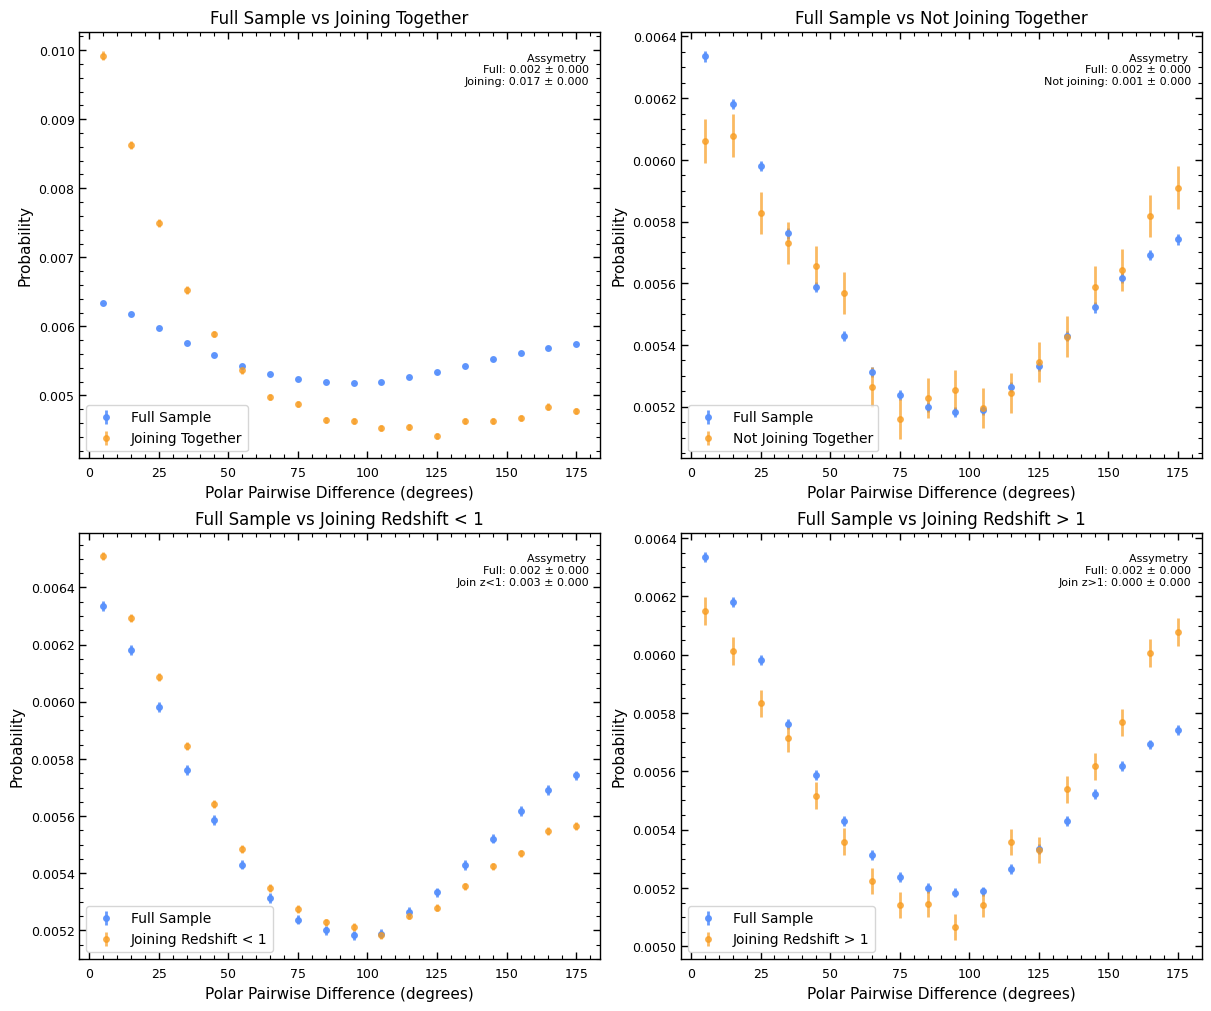

In [13]:
# Now plot 4panel the polar pairwise difference. Top left overlay full sample and joining together. top right overlay full sample and not joining together. bottom left overlay full sample and joining redshift > 1. bottom right overlay full sample and joining redshift < 1.
polarDifference_split_plotter = AstroPlotter()
polarDifference_split_fig, polarDifference_split_ax = polarDifference_split_plotter.create_figure(nrows=2, ncols=2, figsize=(12, 10))
linewidthConst = 2
markersizeConst = 4
polarDifference_split_ax[0, 0].errorbar(polarDifference_full_sample_bincenters, polarDifference_full_sample, yerr=polarDifference_full_sample_err, label='Full Sample', fmt='o', alpha=alphaPrimary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[0, 0].errorbar(polarDifference_joiningTogether_bincenters, polarDifference_joiningTogether, yerr=polarDifference_joiningTogether_err, label='Joining Together', fmt='o', alpha=alphaSecondary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[0, 0].set_xlabel('Polar Pairwise Difference (degrees)')
polarDifference_split_ax[0, 0].set_ylabel('Probability')
polarDifference_split_ax[0, 0].set_title('Full Sample vs Joining Together')
polarDifference_split_ax[0, 0].legend()

polarDifference_split_ax[0, 1].errorbar(polarDifference_full_sample_bincenters, polarDifference_full_sample, yerr=polarDifference_full_sample_err, label='Full Sample', fmt='o', alpha=alphaPrimary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[0, 1].errorbar(polarDifference_notJoiningTogether_bincenters, polarDifference_notJoiningTogether, yerr=polarDifference_notJoiningTogether_err, label='Not Joining Together', fmt='o', alpha=alphaSecondary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[0, 1].set_xlabel('Polar Pairwise Difference (degrees)')
polarDifference_split_ax[0, 1].set_ylabel('Probability')
polarDifference_split_ax[0, 1].set_title('Full Sample vs Not Joining Together')
polarDifference_split_ax[0, 1].legend()

polarDifference_split_ax[1, 0].errorbar(polarDifference_full_sample_bincenters, polarDifference_full_sample, yerr=polarDifference_full_sample_err, label='Full Sample', fmt='o', alpha=alphaPrimary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[1, 0].errorbar(polarDifference_joiningRedshiftLt1_bincenters, polarDifference_joiningRedshiftLt1, yerr=polarDifference_joiningRedshiftLt1_err, label='Joining Redshift < 1', fmt='o', alpha=alphaSecondary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[1, 0].set_xlabel('Polar Pairwise Difference (degrees)')
polarDifference_split_ax[1, 0].set_ylabel('Probability')
polarDifference_split_ax[1, 0].set_title('Full Sample vs Joining Redshift < 1')
polarDifference_split_ax[1, 0].legend()

polarDifference_split_ax[1, 1].errorbar(polarDifference_full_sample_bincenters, polarDifference_full_sample, yerr=polarDifference_full_sample_err, label='Full Sample', fmt='o', alpha=alphaPrimary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[1, 1].errorbar(polarDifference_joiningRedshiftGt1_bincenters, polarDifference_joiningRedshiftGt1, yerr=polarDifference_joiningRedshiftGt1_err, label='Joining Redshift > 1', fmt='o', alpha=alphaSecondary, linewidth=linewidthConst, markersize=markersizeConst)
polarDifference_split_ax[1, 1].set_xlabel('Polar Pairwise Difference (degrees)')
polarDifference_split_ax[1, 1].set_ylabel('Probability')
polarDifference_split_ax[1, 1].set_title('Full Sample vs Joining Redshift > 1')
polarDifference_split_ax[1, 1].legend()



def _asymmetry_text(bincenters, values, errors):
    bc = np.array(bincenters)
    vals = np.array(values, dtype=float)
    errs = np.array(errors, dtype=float) if errors is not None else np.zeros_like(vals)
    lt_mask = bc < 90.0
    n_lt = vals[lt_mask].sum()
    n_ge = vals[~lt_mask].sum()
    diff = n_lt - n_ge
    diff_err = float(np.sqrt((errs[lt_mask] ** 2).sum() + (errs[~lt_mask] ** 2).sum()))
    return diff, diff_err

# compute asymmetries
full_d, full_e = _asymmetry_text(polarDifference_full_sample_bincenters, polarDifference_full_sample, polarDifference_full_sample_err)
jt_d, jt_e = _asymmetry_text(polarDifference_joiningTogether_bincenters, polarDifference_joiningTogether, polarDifference_joiningTogether_err)
nj_d, nj_e = _asymmetry_text(polarDifference_notJoiningTogether_bincenters, polarDifference_notJoiningTogether, polarDifference_notJoiningTogether_err)
lt1_d, lt1_e = _asymmetry_text(polarDifference_joiningRedshiftLt1_bincenters, polarDifference_joiningRedshiftLt1, polarDifference_joiningRedshiftLt1_err)
gt1_d, gt1_e = _asymmetry_text(polarDifference_joiningRedshiftGt1_bincenters, polarDifference_joiningRedshiftGt1, polarDifference_joiningRedshiftGt1_err)

# add annotations to panels (upper-right)
polarDifference_split_ax[0,0].text(0.98, 0.95, f'Assymetry \nFull: {full_d:.3f} ± {full_e:.3f}\nJoining: {jt_d:.3f} ± {jt_e:.3f}', transform=polarDifference_split_ax[0,0].transAxes, ha='right', va='top', fontsize=8)
polarDifference_split_ax[0,1].text(0.98, 0.95, f'Assymetry \nFull: {full_d:.3f} ± {full_e:.3f}\nNot joining: {nj_d:.3f} ± {nj_e:.3f}', transform=polarDifference_split_ax[0,1].transAxes, ha='right', va='top', fontsize=8)
polarDifference_split_ax[1,0].text(0.98, 0.95, f'Assymetry \nFull: {full_d:.3f} ± {full_e:.3f}\nJoin z<1: {lt1_d:.3f} ± {lt1_e:.3f}', transform=polarDifference_split_ax[1,0].transAxes, ha='right', va='top', fontsize=8)
polarDifference_split_ax[1,1].text(0.98, 0.95, f'Assymetry \nFull: {full_d:.3f} ± {full_e:.3f}\nJoin z>1: {gt1_d:.3f} ± {gt1_e:.3f}', transform=polarDifference_split_ax[1,1].transAxes, ha='right', va='top', fontsize=8)





polarDifference_split_plotter.save_figure(
    polarDifference_split_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_split_by_joining_together_and_joining_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

plt.show()

# what is driving the lopsidedness

## remove inconsistent with random MRL and plot MRL and polar piecewise with this separation

In [9]:
#get the subhalos which are inconsistent with random
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=10000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles


final: [np.float64(0.09720930037101629), np.float64(0.07706537088029163), np.float64(0.10948243303477843)]s


In [10]:
(fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values, random_MRL_values=random_MRL_values, percentile=95)
print(len(gg_indices_inconsistent), gg_indices_inconsistent)
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())

105 [0, 1, 2, 3, 4, 5, 6, 12, 15, 17, 20, 23, 24, 25, 27, 29, 30, 39, 40, 50, 52, 54, 58, 60, 62, 64, 65, 68, 69, 71, 72, 73, 74, 77, 79, 83, 85, 86, 87, 92, 96, 98, 100, 101, 102, 103, 106, 107, 108, 111, 116, 120, 126, 130, 132, 135, 136, 140, 145, 146, 148, 149, 157, 158, 162, 168, 173, 174, 176, 178, 179, 180, 186, 193, 197, 199, 204, 210, 213, 215, 216, 217, 225, 226, 227, 228, 229, 232, 236, 238, 239, 243, 244, 252, 256, 258, 259, 261, 263, 266, 270, 276, 277, 278, 279]
280


In [11]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
print(gg_indices_inconsistent)
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())
#see what are the properties of the gg which are inconsistent with random at 99 percentile, and see if they have any common properties among their subhalos which might be driving the lopsidedness in the polar pairwise distribution, and also see if they have any common properties among themselves (e.g. mass, redshift, number of subhalos, etc.)
high_galaxy_groups = []
non_high_galaxy_groups = []
for i, gg in enumerate(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()):
    if i not in gg_indices_inconsistent:
        print(f'Galaxy Group {i} is consistent with random at 95 percentile')
        non_high_galaxy_groups.append(gg)
        continue
    high_galaxy_groups.append(gg)
    # print(f'Galaxy Group ID: {gg.getGroupID()}, M200: {gg.getMCrit200():.4e}, Number of Subhalos: {len(gg.getSubhalos())}')
    # for subhalo in gg.getSubhalos():
        # print(f'  Subhalo ID: {subhalo.getIdx()}, Distance to Group Center: {subhalo.getDistanceToGroupCenter()}, compared to R200: {subhalo.getDistanceToGroupCenter() / gg.getRCrit200()} Joining Redshift: {subhalo.getJoiningRedshift()}, G-R Color: {subhalo.getGbandMagnitude() - subhalo.getRbandMagnitude()}')

[0, 1, 2, 3, 4, 5, 6, 12, 15, 17, 20, 23, 24, 25, 27, 29, 30, 39, 40, 50, 52, 54, 58, 60, 62, 64, 65, 68, 69, 71, 72, 73, 74, 77, 79, 83, 85, 86, 87, 92, 96, 98, 100, 101, 102, 103, 106, 107, 108, 111, 116, 120, 126, 130, 132, 135, 136, 140, 145, 146, 148, 149, 157, 158, 162, 168, 173, 174, 176, 178, 179, 180, 186, 193, 197, 199, 204, 210, 213, 215, 216, 217, 225, 226, 227, 228, 229, 232, 236, 238, 239, 243, 244, 252, 256, 258, 259, 261, 263, 266, 270, 276, 277, 278, 279]
280
Galaxy Group 7 is consistent with random at 95 percentile
Galaxy Group 8 is consistent with random at 95 percentile
Galaxy Group 9 is consistent with random at 95 percentile
Galaxy Group 10 is consistent with random at 95 percentile
Galaxy Group 11 is consistent with random at 95 percentile
Galaxy Group 13 is consistent with random at 95 percentile
Galaxy Group 14 is consistent with random at 95 percentile
Galaxy Group 16 is consistent with random at 95 percentile
Galaxy Group 18 is consistent with random at 95 pe

high len: 105
nonhigh len: 175
COMPUTING FOR redshift index: 0, label: High Galaxy Groups(Inconsistent with Random MRL at 95% CL)
Total Galaxy Groups to process: 105 with pairs : 1032289
Progress: Processing Galaxy Group ID 0, 1 / 105

Progress: Processing Galaxy Group ID 99, 105 / 105COMPUTING FOR redshift index: 0, label: Non-High Galaxy Groups (Consistent with Random MRL at 95% CL)
Total Galaxy Groups to process: 175 with pairs : 721613
Progress: Processing Galaxy Group ID 95, 175 / 1755
now plotting MRL

running label with list: 105
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029163), np.float64(0.10948243303477843)]
Fraction of MRL values below the 95th percentile of random MRL values: 0.3270 (103/315)with 55 satellitess
running label with list: 175
Fraction of MRL values below the 95th percentile of random MRL values: 0.9981 (524/525)with 86 satellitess


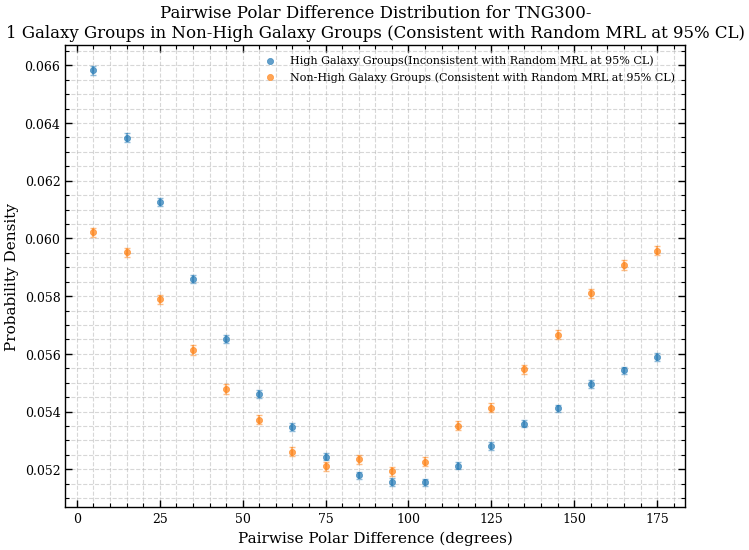

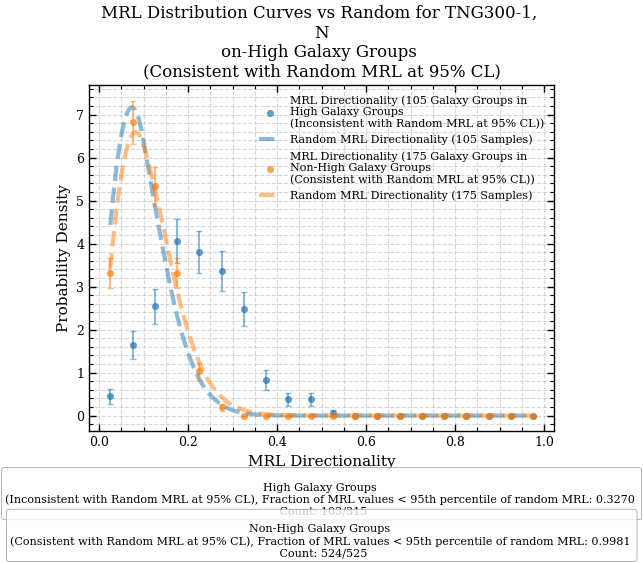

In [17]:
high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)
print(f"high len: {len(high_list_galaxy_groups.getAllGalaxyGroups())}")
print(f"nonhigh len: {len(non_high_list_galaxy_groups.getAllGalaxyGroups())}")

#plot polar pairwise distribution for the high galaxy groups and the non-high galaxy groups, and see if the lopsidedness in the polar pairwise distribution is being really driven by just a few (which we won't see in mrl since its cluster by cluster).
high_nonhigh_polar_plot, high_nonhigh_fig, high_nonhigh_ax = galaxyAnalysisSnapshot.overlay_polar_pairwise_across_redshifts([
    [(high_list_galaxy_groups, "High Galaxy Groups(Inconsistent with Random MRL at 95% CL)"),
    (non_high_list_galaxy_groups, "Non-High Galaxy Groups (Consistent with Random MRL at 95% CL)")]],
    oneaxis=True, 
)

high_nonhigh_ax.legend(fontsize=8)

print("\nnow plotting MRL\n")

#plot MRL
high_nonhigh_MRL_plot, high_nonhigh_MRL_fig, high_nonhigh_MRL_ax = galaxyAnalysisSnapshot.overlayMRLAndMRLRandom([
    (high_list_galaxy_groups, "\nHigh Galaxy Groups \n(Inconsistent with Random MRL at 95% CL)"),
    (non_high_list_galaxy_groups, "\nNon-High Galaxy Groups \n(Consistent with Random MRL at 95% CL)")],
    filename='mrl_difference_high_nonhigh', oneaxis=True, savefig=False, percentageMRL=95
)